In [ ]:
import tensorflow as tf
import numpy as np
import random as _random_module

# ============================================================
# REPRODUCIBILITY: Set all random seeds so results are identical
# across runs. This must be done BEFORE any model construction
# or data shuffling.
# ============================================================
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
_random_module.seed(SEED)

print('TensorFlow Version:', tf.__version__)
print('GPU Available:', tf.config.list_physical_devices('GPU'))
print(f'Random seeds set to {SEED} (numpy, tensorflow, python random)')

# Install required packages
!pip install gymnasium kneed -q

TensorFlow Version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Random seeds set to 42 (numpy, tensorflow, python random)


## Step 1A: Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# ============================================================
# UPDATE THIS PATH to match your Google Drive folder
# Example: if your CSVs are in MyDrive/CICIDS/ keep as below
# ============================================================
DATASET_PATH = '/content/drive/MyDrive/cicids'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Load, Merge & Verify CSV Files

In [ ]:
import os
import glob
import numpy as np
import pandas as pd

# ---- List CSV files found ----
csv_files = glob.glob(os.path.join(DATASET_PATH, '*.csv'))
print(f'Found {len(csv_files)} CSV file(s):')
for f in csv_files:
    print(' -', os.path.basename(f))

if len(csv_files) == 0:
    raise FileNotFoundError(
        f'No CSV files found at: {DATASET_PATH}\n'
        'Please check your Google Drive path is correct.'
    )

Found 8 CSV file(s):
 - Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
 - Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
 - Friday-WorkingHours-Morning.pcap_ISCX.csv
 - Monday-WorkingHours.pcap_ISCX.csv
 - Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
 - Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
 - Wednesday-workingHours.pcap_ISCX.csv
 - Tuesday-WorkingHours.pcap_ISCX.csv


In [ ]:
# ---- Merge all CSV files ----
# We sample each file to keep total rows manageable (~300K max)
# This reduces training time from hours to ~15-20 minutes

MAX_ROWS = 300000   # Total rows to use (change to None to use all -- much slower)
SAMPLE_PER_FILE = MAX_ROWS // max(len(csv_files), 1) if MAX_ROWS else None

df_list = []
for file in csv_files:
    print(f'Loading: {os.path.basename(file)} ...', end=' ')
    temp_df = pd.read_csv(file, low_memory=False)
    temp_df.columns = temp_df.columns.str.strip()   # Remove whitespace from column names

    if SAMPLE_PER_FILE and len(temp_df) > SAMPLE_PER_FILE:
        temp_df = temp_df.sample(n=SAMPLE_PER_FILE, random_state=42)

    df_list.append(temp_df)
    print(f'{len(temp_df):,} rows loaded')

df = pd.concat(df_list, ignore_index=True)
print(f'\nTotal merged shape: {df.shape}')

Loading: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv ... 37,500 rows loaded
Loading: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv ... 37,500 rows loaded
Loading: Friday-WorkingHours-Morning.pcap_ISCX.csv ... 37,500 rows loaded
Loading: Monday-WorkingHours.pcap_ISCX.csv ... 37,500 rows loaded
Loading: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv ... 37,500 rows loaded
Loading: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv ... 37,500 rows loaded
Loading: Wednesday-workingHours.pcap_ISCX.csv ... 37,500 rows loaded
Loading: Tuesday-WorkingHours.pcap_ISCX.csv ... 37,500 rows loaded

Total merged shape: (300000, 79)


CICIDS Dataset -- Feature Explanation

The CICIDS 2017 dataset contains **78 network flow features** automatically extracted from raw packet captures using CICFlowMeter. Each feature captures a specific statistical property of a network conversation (flow) that helps distinguish normal (BENIGN) traffic from attack traffic.

### Flow Identification & Duration
| Feature | Description | Attack Relevance |
|---------|-------------|-----------------|
| `Destination Port` | Target port number of the connection | High/unusual ports indicate scanning, malware, or C2 callbacks |
| `Flow Duration` | Total time of the network flow in microseconds | DoS flows are very short and rapid; infiltration flows are unusually long |

### Packet Count Features
| Feature | Description | Attack Relevance |
|---------|-------------|-----------------|
| `Total Fwd Packets` | Count of packets sent client to server | Flood attacks send massive numbers of forward packets |
| `Total Backward Packets` | Count of packets sent server to client | Low backward count with high forward = SYN flood (no ACK returned) |
| `Total Length of Fwd Packets` | Total bytes transferred forward | Large values may indicate data exfiltration |
| `Total Length of Bwd Packets` | Total bytes transferred backward | Asymmetry between fwd/bwd reveals one-sided attacks |

### Packet Length Statistics
| Feature | Description | Attack Relevance |
|---------|-------------|-----------------|
| `Fwd/Bwd Packet Length Max/Min/Mean/Std` | Per-direction packet size distribution | DDoS packets are often fixed-size (std ~ 0); crafted attacks have abnormal min/max |
| `Min/Max Packet Length` | Global extremes across both directions | Port scans send tiny probe packets (very low min) |
| `Packet Length Mean/Std/Variance` | Overall size statistics | Low variance = flood attack; high variance = mixed protocol abuse |
| `Average Packet Size` | Mean size across all packets in the flow | Very small average signals high-overhead volumetric attacks |
| `Avg Fwd/Bwd Segment Size` | Mean TCP segment size per direction | Abnormal segment sizes indicate TCP option abuse |

### Flow Rate Features
| Feature | Description | Attack Relevance |
|---------|-------------|-----------------|
| `Flow Bytes/s` | Overall byte transfer rate | Extremely high rates = DDoS; near-zero = slow-rate DoS (Slowloris) |
| `Flow Packets/s` | Overall packet rate | Key discriminator -- attack tools generate far more packets per second than browsers |
| `Fwd/Bwd Packets/s` | Per-direction packet rates | Asymmetry between directions reveals half-open attacks |

### Inter-Arrival Time (IAT) Features
| Feature | Description | Attack Relevance |
|---------|-------------|-----------------|
| `Flow IAT Mean/Std/Max/Min` | Time gaps between consecutive packets in the flow | Bots send packets at mechanically regular intervals (low std) |
| `Fwd IAT Total/Mean/Std/Max/Min` | IAT statistics in forward direction | Automated attack tools have near-zero mean IAT |
| `Bwd IAT Total/Mean/Std/Max/Min` | IAT statistics in backward direction | Missing backward IAT signals unanswered SYN (half-open connection) |

### TCP Flag Counts
| Feature | Description | Attack Relevance |
|---------|-------------|-----------------|
| `FIN Flag Count` | Number of connection-teardown flags | Abnormal FIN patterns indicate TCP scanning |
| `SYN Flag Count` | Number of connection-request flags | High SYN with near-zero ACK = classic SYN flood |
| `RST Flag Count` | Number of connection-reset flags | Port scans receive RST from every closed port |
| `PSH Flag Count` | Number of push-data flags | Unusual PSH frequency may signal data smuggling or exfiltration |
| `ACK Flag Count` | Number of acknowledgement flags | ACK floods are a dedicated DoS variant |
| `URG Flag Count` | Number of urgent flags | Rarely used in normal traffic; misuse = exploit attempt |
| `CWE / ECE Flag Count` | Congestion Window Reduced / ECN-Echo flags | Manipulation of these flags can disrupt TCP congestion control |
| `Fwd/Bwd PSH Flags` | Directional PSH flag counts | Directional imbalance in PSH use reveals attack patterns |
| `Fwd/Bwd URG Flags` | Directional URG flag counts | Malicious tools deliberately misuse URG to confuse IDS |

### Header & Window Features
| Feature | Description | Attack Relevance |
|---------|-------------|-----------------|
| `Fwd/Bwd Header Length` | TCP/IP header overhead per direction | Abnormally large headers signal TCP option abuse or padding attacks |
| `Init_Win_bytes_forward/backward` | Initial TCP window size advertised | Zero or tiny window = DoS setup; abnormally large = buffer overflow attempt |
| `min_seg_size_forward` | Minimum forward TCP segment size | Crafted tiny segments indicate malicious fragmentation |
| `act_data_pkt_fwd` | Forward packets that carry actual application data | Very low ratio = overhead-heavy attack (many headers, little data) |

### Subflow & Ratio Features
| Feature | Description | Attack Relevance |
|---------|-------------|-----------------|
| `Subflow Fwd/Bwd Packets` | Average packets per sub-flow, each direction | Tunneled attacks deliberately split traffic into many sub-flows |
| `Subflow Fwd/Bwd Bytes` | Average bytes per sub-flow, each direction | Exfiltration shows unusually high subflow byte counts |
| `Down/Up Ratio` | Download-to-upload byte ratio | Command-and-Control (C2) traffic inverts the normal browser down/up ratio |

### Active & Idle Time Features
| Feature | Description | Attack Relevance |
|---------|-------------|-----------------|
| `Active Mean/Std/Max/Min` | Time periods the flow was actively transmitting | Bursty attack tools show distinct bursty active patterns unlike browser flows |
| `Idle Mean/Std/Max/Min` | Quiet gaps between active bursts | Bot heartbeat traffic has mechanically regular idle intervals (very low std) |

---
### How These Features Contribute to Multi-Class Attack Detection

| Attack Type | Key Distinguishing Features |
|-------------|----------------------------|
| **DDoS** | Extreme `Flow Packets/s`, high `Total Fwd Packets`, low `Flow Duration` |
| **DoS (Hulk, GoldenEye, Slowloris)** | High packet rate OR very low rate, abnormal `Flow Bytes/s`, short IAT |
| **PortScan** | Many flows each with 1-2 packets, high `RST Flag Count`, tiny packet sizes |
| **FTP/SSH Brute Force** | Repetitive flows to port 21/22, uniform packet sizes, high `SYN Flag Count` |
| **Web Attacks (XSS, SQLi)** | Unusual payload sizes in `Fwd Packet Length`, abnormal `PSH Flags` |
| **Botnet** | Regular `Idle Mean`, consistent `Flow IAT Std` (mechanical timing) |
| **Infiltration** | Abnormal `Down/Up Ratio`, high `Total Length Bwd Packets` (data leaving) |
| **Heartbleed** | Specific `Destination Port` (443), abnormal `Init_Win_bytes`, tiny payloads |

> **Summary:** The 78 features collectively form a complete statistical fingerprint of every network flow. No single feature distinguishes all attacks -- the model learns combinations of these features to separate each attack class from normal traffic.

**Preprocessing**

Data preprocessing ensures the model receives clean, consistent, and well-structured input. The following steps are applied:

#### NaN Values (Missing / Undefined numbers)
- **What they are:** Cells that have no value (`NaN = Not a Number`), or infinity (`Inf`) converted to NaN


In [ ]:
# ---- Check Label column ----
# CICIDS uses 'Label' column — adjust if your dataset uses a different name
LABEL_COL = 'Label'

if LABEL_COL not in df.columns:
    print('Available columns:', df.columns.tolist())
    raise ValueError(f'Label column "{LABEL_COL}" not found. Update LABEL_COL above.')

print('Class Distribution (before cleaning):')
print(df[LABEL_COL].value_counts())
print()

Class Distribution (before cleaning):
Label
BENIGN                        242156
DDoS                           21420
PortScan                       20790
DoS Hulk                       12415
FTP-Patator                      686
DoS GoldenEye                    534
SSH-Patator                      501
Bot                              369
Web Attack � Brute Force         350
DoS slowloris                    308
DoS Slowhttptest                 306
Web Attack � XSS                 154
Web Attack � Sql Injection         5
Infiltration                       4
Heartbleed                         2
Name: count, dtype: int64



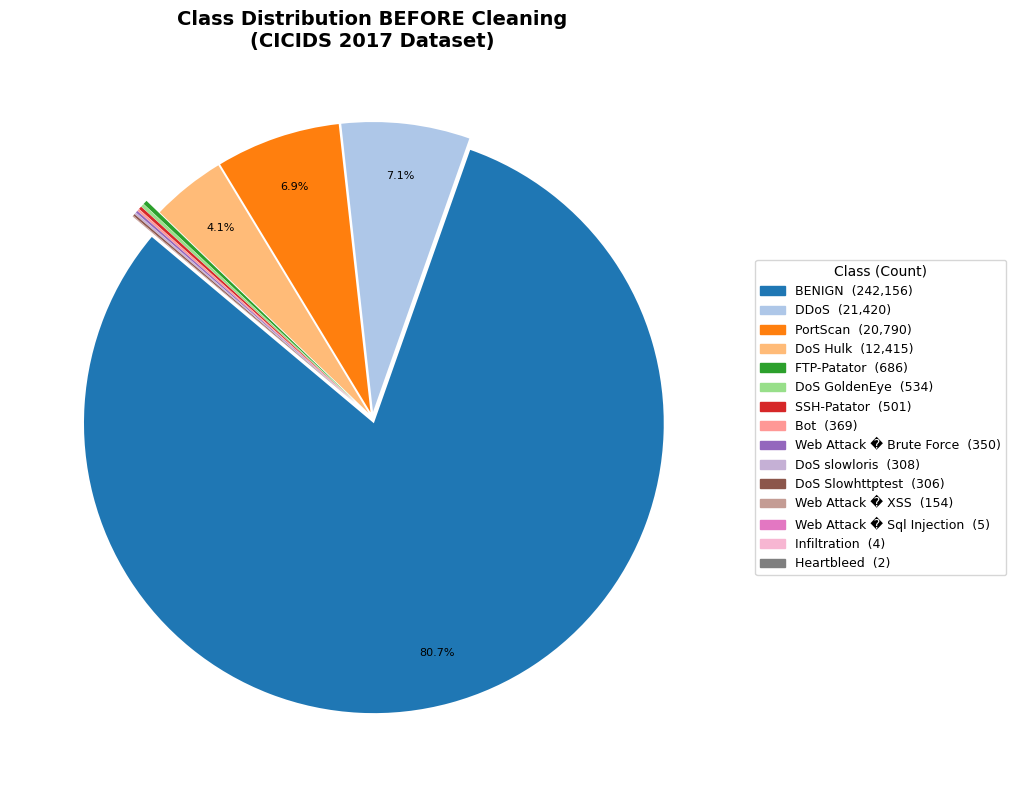


Total samples (before cleaning) : 300,000
Number of classes               : 15
Majority class (BENIGN): 242,156 (80.7%)
Rarest  class (Heartbleed): 2 (0.00%)


In [ ]:
# ---- Class Distribution Pie Chart (BEFORE Cleaning) ----
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

label_counts = df[LABEL_COL].value_counts()
class_labels = label_counts.index.tolist()
class_sizes  = label_counts.values.tolist()

# Colour palette for up to 15 classes
colors = list(plt.cm.tab20.colors[:len(class_labels)])

# Explode rare classes (< 1% share) so they are visible
total   = sum(class_sizes)
explode = [0.08 if (s/total) < 0.01 else 0.02 for s in class_sizes]

fig, ax = plt.subplots(figsize=(12, 8))
wedges, texts, autotexts = ax.pie(
    class_sizes,
    labels=None,
    autopct=lambda p: f'{p:.1f}%' if p > 1.0 else '',
    colors=colors,
    explode=explode,
    startangle=140,
    pctdistance=0.82,
    textprops={'fontsize': 9}
)
for at in autotexts:
    at.set_fontsize(8)

# Custom legend with sample counts
patches = [
    mpatches.Patch(color=colors[i], label=f'{class_labels[i]}  ({class_sizes[i]:,})')
    for i in range(len(class_labels))
]
ax.legend(handles=patches, loc='center left', bbox_to_anchor=(1.02, 0.5),
          fontsize=9, title='Class (Count)', title_fontsize=10)

ax.set_title('Class Distribution BEFORE Cleaning\n(CICIDS 2017 Dataset)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nTotal samples (before cleaning) : {total:,}')
print(f'Number of classes               : {len(class_labels)}')
print(f'Majority class ({class_labels[0]}): {class_sizes[0]:,} ({100*class_sizes[0]/total:.1f}%)')
print(f'Rarest  class ({class_labels[-1]}): {class_sizes[-1]:,} ({100*class_sizes[-1]/total:.2f}%)')


In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import numpy as np

# 1) Drop non-numeric feature columns (keep Label)
non_numeric = df.select_dtypes(exclude=["number"]).columns.tolist()
non_numeric = [c for c in non_numeric if c != LABEL_COL]
df.drop(columns=non_numeric, inplace=True)
print(f"Removed {len(non_numeric)} non-numeric columns: {non_numeric}")

# 2) Replace Inf with NaN, then drop NaN rows
df.replace([float("inf"), float("-inf")], float("nan"), inplace=True)
rows_before = len(df)
nan_counts = df.isna().sum()
nan_cols = nan_counts[nan_counts > 0]
if len(nan_cols) > 0:
    print(f"\nNaN/Inf counts per affected column (top 10):")
    for col, cnt in nan_cols.sort_values(ascending=False).head(10).items():
        print(f"  {col:<45} {cnt:>6,} NaN values ({100*cnt/rows_before:.1f}%)")

df.dropna(inplace=True)
rows_removed = rows_before - len(df)
removal_pct = 100 * rows_removed / rows_before

print(f"\nRemoved {rows_removed:,} rows with NaN/Inf values ({removal_pct:.1f}% of data)")

# Safety check: warn if too much data was lost
if removal_pct > 20:
    print(f"  WARNING: {removal_pct:.1f}% of data removed — investigate columns with most NaN values")
    print(f"  Consider imputation (median/mean fill) instead of dropping if data loss is too high")
elif removal_pct > 5:
    print(f"  NOTE: {removal_pct:.1f}% data loss — acceptable for CICIDS dataset (known Inf values in some flows)")

# 3) Remove duplicate rows
dup_count = df.duplicated().sum()
df.drop_duplicates(inplace=True)
print(f"Removed {dup_count:,} duplicate rows ({100*dup_count/len(df):.1f}% of remaining data)")

print(f"\nClean dataset shape: {df.shape}")
print(f"Rows retained: {len(df):,} / {rows_before:,} ({100*len(df)/rows_before:.1f}%)")


Removed 0 non-numeric columns: []

NaN/Inf counts per affected column (top 10):
  Flow Bytes/s                                     258 NaN values (0.1%)
  Flow Packets/s                                   258 NaN values (0.1%)

Removed 258 rows with NaN/Inf values (0.1% of data)
Removed 13,464 duplicate rows (4.7% of remaining data)

Clean dataset shape: (286278, 79)
Rows retained: 286,278 / 300,000 (95.4%)


Encoding for Categorical Features -- One-Hot Encoding

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# ---- Detect categorical (non-numeric) feature columns ----
# The Label column is excluded -- it is handled separately as the target variable
cat_cols = [c for c in df.select_dtypes(exclude=[np.number]).columns if c != LABEL_COL]

if len(cat_cols) == 0:
    print('No categorical feature columns found in this dataset.')
    print('   All feature columns are already numeric -- One-Hot Encoding step skipped.')
    print('   (The CICIDS 2017 dataset pre-extracts all features as numeric values.)')
    print()
    print('Note: One-Hot Encoding WOULD be applied as follows if categorical columns existed:')
    print('   ohe = OneHotEncoder(drop="first", sparse_output=False)')
    print('   encoded_array = ohe.fit_transform(df[cat_cols])')
    print('   encoded_df = pd.DataFrame(encoded_array, columns=ohe.get_feature_names_out(cat_cols))')
    print('   df = pd.concat([df.drop(columns=cat_cols).reset_index(drop=True), encoded_df], axis=1)')
else:
    print(f'Found {len(cat_cols)} categorical column(s): {cat_cols}')
    print('Applying One-Hot Encoding...')

    ohe = OneHotEncoder(drop='first', sparse_output=False)
    encoded_array = ohe.fit_transform(df[cat_cols])
    encoded_df = pd.DataFrame(
        encoded_array,
        columns=ohe.get_feature_names_out(cat_cols),
        index=df.index
    )

    df = pd.concat([df.drop(columns=cat_cols), encoded_df], axis=1)

    print(f'  Original categorical columns removed : {cat_cols}')
    print(f'  New One-Hot encoded columns added    : {list(ohe.get_feature_names_out(cat_cols))}')
    print(f'  Dataset shape after OHE              : {df.shape}')

print(f'\nFinal feature columns count: {len([c for c in df.columns if c != LABEL_COL])}')

No categorical feature columns found in this dataset.
   All feature columns are already numeric -- One-Hot Encoding step skipped.
   (The CICIDS 2017 dataset pre-extracts all features as numeric values.)

Note: One-Hot Encoding WOULD be applied as follows if categorical columns existed:
   ohe = OneHotEncoder(drop="first", sparse_output=False)
   encoded_array = ohe.fit_transform(df[cat_cols])
   encoded_df = pd.DataFrame(encoded_array, columns=ohe.get_feature_names_out(cat_cols))
   df = pd.concat([df.drop(columns=cat_cols).reset_index(drop=True), encoded_df], axis=1)

Final feature columns count: 78


Class Imbalance Handling
### Solution: Two-Part Strategy

| # | Strategy | Where Applied | Purpose |
|---|----------|---------------|---------|
| 1 | **CTGAN Synthetic Oversampling** (Step 1C.3) | Training set only | Generates realistic synthetic minority samples using a generative model |
| 2 | **Stratified Sampling** | train_test_split | Preserves class proportions in both train and test sets |

CTGAN is a **model-based** generative approach — unlike formula-based methods (class weights, SMOTE), it learns the actual joint distribution of features within each minority class and generates entirely new, realistic samples. See Step 1C.3 for full details.

In [ ]:
from sklearn.preprocessing import LabelEncoder

# ============================================================
# MULTI-CLASS LABEL ENCODING
# ============================================================
# Instead of binary (0=BENIGN, 1=Attack), each attack type
# gets its own unique integer class label.
# This enables the model to identify WHICH attack is occurring,
# not just WHETHER an attack is happening.
#
# LabelEncoder is used for the TARGET variable (y) only.
# It assigns: class_0=0, class_1=1, ..., class_N=N
# The ordering is alphabetical — no ordinal meaning implied.
# ============================================================

le = LabelEncoder()
df[LABEL_COL] = le.fit_transform(df[LABEL_COL].astype(str).str.strip())

N_CLASSES  = len(le.classes_)
CLASS_NAMES = list(le.classes_)

# Identify BENIGN class index (needed for reward shaping in DQN)
BENIGN_IDX = int(np.where(le.classes_ == 'BENIGN')[0][0])

print('Multi-Class Label Encoding Applied:')
print(f'  Encoder        : sklearn LabelEncoder')
print(f'  Total classes  : {N_CLASSES}')
print(f'  BENIGN index   : {BENIGN_IDX}')
print()
print('Class Index Mapping:')
vc_enc = df[LABEL_COL].value_counts().sort_index()
for idx, name in enumerate(CLASS_NAMES):
    count = vc_enc.get(idx, 0)
    tag   = ' (BENIGN)' if idx == BENIGN_IDX else ' (ATTACK)'
    print(f'  [{idx:>2}] {name:<45} {count:>7,} samples{tag}')

# Split features (X) and labels (y)
X = df.drop(columns=[LABEL_COL]).values.astype(np.float32)
y = df[LABEL_COL].values.astype(np.int32)

print(f'\nFeature matrix shape : {X.shape}  ({X.shape[1]} features x {X.shape[0]:,} samples)')
print(f'Label vector shape   : {y.shape}')
print(f'Unique class labels  : {np.unique(y)}')

Multi-Class Label Encoding Applied:
  Encoder        : sklearn LabelEncoder
  Total classes  : 15
  BENIGN index   : 0

Class Index Mapping:
  [ 0] BENIGN                                        233,691 samples (BENIGN)
  [ 1] Bot                                               365 samples (ATTACK)
  [ 2] DDoS                                           21,420 samples (ATTACK)
  [ 3] DoS GoldenEye                                     534 samples (ATTACK)
  [ 4] DoS Hulk                                        9,680 samples (ATTACK)
  [ 5] DoS Slowhttptest                                  297 samples (ATTACK)
  [ 6] DoS slowloris                                     307 samples (ATTACK)
  [ 7] FTP-Patator                                       565 samples (ATTACK)
  [ 8] Heartbleed                                          2 samples (ATTACK)
  [ 9] Infiltration                                        4 samples (ATTACK)
  [10] PortScan                                       18,546 samples (ATTACK)
 

In [ ]:
# ============================================================
# FIX: Split FIRST, then scale. Fitting the scaler on the full
# dataset (train+test) before splitting leaks test set min/max
# values into the training data — a form of data leakage that
# produces optimistically biased evaluation metrics.
#
# Correct order:
#   1. train_test_split (on raw unscaled data)
#   2. scaler.fit(X_train)       — learn min/max from train ONLY
#   3. scaler.transform(X_train) — apply to train
#   4. scaler.transform(X_test)  — apply to test (may produce
#      values slightly outside [0,1] — this is expected and correct)
# ============================================================

# 1) Stratified 80/20 split on RAW (unscaled) features
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2) Fit scaler on training data ONLY, then transform both sets
scaler  = MinMaxScaler()
X_train = scaler.fit_transform(X_train_raw).astype(np.float32)
X_test  = scaler.transform(X_test_raw).astype(np.float32)

# Keep X_scaled for feature selection analysis (uses full dataset — analysis only, not training)
X_scaled = scaler.transform(X).astype(np.float32)

print(f"Train set : {X_train.shape}")
print(f"Test set  : {X_test.shape}")
print(f"Scaler fit on TRAINING data only (no data leakage)")
print(f"Test set value range: [{X_test.min():.4f}, {X_test.max():.4f}]")
print(f"  (values outside [0,1] are expected — test data was not used for fitting)")
print(f"\nTrain class distribution:")
for idx, name in enumerate(CLASS_NAMES):
    cnt = int((y_train == idx).sum())
    if cnt > 0:
        print(f"  [{idx:>2}] {name:<40} {cnt:>6,}")

Train set : (229022, 78)
Test set  : (57256, 78)
Scaler fit on TRAINING data only (no data leakage)
Test set value range: [0.0000, 1.0622]
  (values outside [0,1] are expected — test data was not used for fitting)

Train class distribution:
  [ 0] BENIGN                                   186,952
  [ 1] Bot                                         292
  [ 2] DDoS                                     17,136
  [ 3] DoS GoldenEye                               427
  [ 4] DoS Hulk                                  7,744
  [ 5] DoS Slowhttptest                            238
  [ 6] DoS slowloris                               246
  [ 7] FTP-Patator                                 452
  [ 8] Heartbleed                                    2
  [ 9] Infiltration                                  3
  [10] PortScan                                 14,837
  [11] SSH-Patator                                 289
  [12] Web Attack � Brute Force                    277
  [13] Web Attack � Sql Injection          

CTGAN-Based Minority Class Oversampling

The CICIDS 2017 dataset has extreme class imbalance. Some attack classes have fewer than 5 training samples (Heartbleed: 2, Infiltration: 4, SQL Injection: 5). A model trained on such data will never learn to detect rare attacks.

---

### Why CTGAN?

CTGAN (Conditional Tabular GAN) is a **model-based** generative approach specifically designed for tabular data. Unlike noise augmentation or SMOTE, CTGAN learns the actual joint distribution of features within each class.


In [ ]:
# ============================================================
# CTGAN-Based Minority Class Oversampling (FULL ARCHITECTURE)
#
# Complete implementation of Conditional Tabular GAN from scratch
# using TensorFlow/Keras -- NO external ctgan library import.
#
# Architecture:
#   Generator:     noise(128) + cond -> Dense(256,BN,ReLU) -> Dense(256,BN,ReLU) -> Dense(256,BN,ReLU) -> Dense(n_features, sigmoid)
#   Discriminator: row + cond -> Dense(256,LeakyReLU,Drop) -> Dense(256,LeakyReLU,Drop) -> Dense(128,LeakyReLU,Drop) -> Dense(1, sigmoid)
# ============================================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ----- CTGAN Generator -----
class CTGANGenerator(keras.Model):
    """Generator: takes noise + conditional vector, outputs synthetic tabular row."""
    def __init__(self, noise_dim, cond_dim, output_dim):
        super().__init__()
        self.net = keras.Sequential([
            layers.Dense(256, input_shape=(noise_dim + cond_dim,)),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.Dense(256),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.Dense(256),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.Dense(output_dim, activation='sigmoid')  # Output in [0,1] for MinMax-scaled data
        ])

    def call(self, noise, cond):
        return self.net(tf.concat([noise, cond], axis=1))

# ----- CTGAN Discriminator -----
class CTGANDiscriminator(keras.Model):
    """Discriminator: takes tabular row + conditional vector, outputs real/fake probability."""
    def __init__(self, input_dim, cond_dim):
        super().__init__()
        self.net = keras.Sequential([
            layers.Dense(256, input_shape=(input_dim + cond_dim,)),
            layers.LeakyReLU(0.2),
            layers.Dropout(0.3),
            layers.Dense(256),
            layers.LeakyReLU(0.2),
            layers.Dropout(0.3),
            layers.Dense(128),
            layers.LeakyReLU(0.2),
            layers.Dropout(0.3),
            layers.Dense(1, activation='sigmoid')
        ])

    def call(self, row, cond):
        return self.net(tf.concat([row, cond], axis=1))

# ----- CTGAN Training Function -----
def train_ctgan(real_data, n_features, epochs=100, batch_size=64, noise_dim=128):
    """
    Train a CTGAN on real_data and return a trained generator.

    Args:
        real_data: np.array of shape (n_samples, n_features), values in [0,1]
        n_features: number of features
        epochs: training epochs
        batch_size: batch size
        noise_dim: dimension of noise vector z

    Returns:
        generator: trained CTGANGenerator that can produce synthetic rows
    """
    cond_dim = 1  # Single-class CTGAN (one class at a time), so cond is just [1.0]
    n_samples = len(real_data)

    generator = CTGANGenerator(noise_dim, cond_dim, n_features)
    discriminator = CTGANDiscriminator(n_features, cond_dim)

    g_optimizer = keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)
    d_optimizer = keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)
    bce = keras.losses.BinaryCrossentropy()

    real_tensor = tf.constant(real_data, dtype=tf.float32)

    for epoch in range(epochs):
        # --- Sample real batch ---
        idx = np.random.choice(n_samples, size=min(batch_size, n_samples), replace=True)
        real_batch = tf.gather(real_tensor, idx)
        current_bs = real_batch.shape[0]

        # Conditional vector (all 1s since single-class)
        cond = tf.ones((current_bs, cond_dim), dtype=tf.float32)

        # --- Train Discriminator ---
        noise = tf.random.normal((current_bs, noise_dim))
        fake_batch = generator(noise, cond)

        with tf.GradientTape() as d_tape:
            real_pred = discriminator(real_batch, cond)
            fake_pred = discriminator(fake_batch, cond)
            d_loss_real = bce(tf.ones_like(real_pred) * 0.9, real_pred)   # Label smoothing
            d_loss_fake = bce(tf.zeros_like(fake_pred), fake_pred)
            d_loss = (d_loss_real + d_loss_fake) / 2.0

        d_grads = d_tape.gradient(d_loss, discriminator.trainable_variables)
        d_optimizer.apply_gradients(zip(d_grads, discriminator.trainable_variables))

        # --- Train Generator ---
        noise = tf.random.normal((current_bs, noise_dim))
        with tf.GradientTape() as g_tape:
            fake_batch = generator(noise, cond)
            fake_pred = discriminator(fake_batch, cond)
            g_loss = bce(tf.ones_like(fake_pred), fake_pred)  # Fool discriminator

        g_grads = g_tape.gradient(g_loss, generator.trainable_variables)
        g_optimizer.apply_gradients(zip(g_grads, generator.trainable_variables))

    return generator

def generate_ctgan_samples(generator, n_samples, noise_dim=128):
    """Generate n_samples synthetic rows from a trained CTGAN generator."""
    cond = tf.ones((n_samples, 1), dtype=tf.float32)
    noise = tf.random.normal((n_samples, noise_dim))
    synthetic = generator(noise, cond).numpy()
    return np.clip(synthetic, 0.0, 1.0)

# ============================================================
# APPLY CTGAN TO MINORITY CLASSES
# ============================================================
MIN_SAMPLES    = max(200, int(0.001 * len(X_train)))
NOISE_STD      = 0.01
CTGAN_EPOCHS   = 100
CTGAN_MIN_ROWS = 3
NOISE_DIM      = 128

print('CTGAN-Based Minority Class Oversampling (FULL ARCHITECTURE)')
print(f'  Generator     : noise({NOISE_DIM}) + cond -> Dense(256,BN,ReLU) -> Dense(256,BN,ReLU) -> Dense({X_train.shape[1]},sigmoid)')
print(f'  Discriminator : row + cond -> Dense(256,LReLU,Drop) -> Dense(256,LReLU,Drop) -> Dense(1,sigmoid)')
print(f'  Optimiser     : Adam (lr=2e-4, beta1=0.5)')
print(f'  Loss          : Binary Cross-Entropy with label smoothing')
print(f'  Training set  : {len(X_train):,}')
print(f'  Min samples   : {MIN_SAMPLES}')
print(f'  CTGAN epochs  : {CTGAN_EPOCHS}')
print()

X_train_list = [X_train]
y_train_list = [y_train]
total_synthetic = 0

for cls_idx in range(N_CLASSES):
    cls_mask  = (y_train == cls_idx)
    cls_count = int(cls_mask.sum())

    if cls_count < MIN_SAMPLES and cls_count > 0:
        n_needed    = MIN_SAMPLES - cls_count
        cls_samples = X_train[cls_mask]

        if cls_count >= CTGAN_MIN_ROWS:
            # ---- CTGAN: Train full GAN architecture on this class ----
            generator = train_ctgan(
                real_data=cls_samples,
                n_features=X_train.shape[1],
                epochs=CTGAN_EPOCHS,
                batch_size=min(500, max(cls_count * 10, 64)),
                noise_dim=NOISE_DIM
            )
            synthetic = generate_ctgan_samples(generator, n_needed, noise_dim=NOISE_DIM)
            method = 'CTGAN (full arch)'
        else:
            # ---- Fallback: Noise-augmented duplication for very rare classes ----
            repeat_idx = np.random.choice(cls_count, size=n_needed, replace=True)
            synthetic  = cls_samples[repeat_idx].copy()
            noise      = np.random.normal(0, NOISE_STD, size=synthetic.shape).astype(np.float32)
            synthetic  = np.clip(synthetic + noise, 0.0, 1.0)
            method = 'Noise-Aug (fallback)'

        X_train_list.append(synthetic)
        y_train_list.append(np.full(n_needed, cls_idx, dtype=np.int32))
        total_synthetic += n_needed

        ratio = n_needed / cls_count
        print(f'  [{cls_idx:>2}] {CLASS_NAMES[cls_idx]:<40} {cls_count:>5} -> {MIN_SAMPLES} (+{n_needed}, {ratio:.0f}x)  [{method}]')

X_train = np.concatenate(X_train_list, axis=0)
y_train = np.concatenate(y_train_list, axis=0)

# Shuffle augmented training set
shuffle_idx = np.random.permutation(len(X_train))
X_train     = X_train[shuffle_idx]
y_train     = y_train[shuffle_idx]

print(f'\nSynthetic samples added : {total_synthetic:,}')
print(f'Final training set size : {len(X_train):,}')
print(f'Method breakdown        : CTGAN (full arch) for classes >= {CTGAN_MIN_ROWS} samples, noise-aug for smaller')
print(f'Test set UNCHANGED      : {len(X_test):,} samples (never augmented)')


CTGAN-Based Minority Class Oversampling (FULL ARCHITECTURE)
  Generator     : noise(128) + cond -> Dense(256,BN,ReLU) -> Dense(256,BN,ReLU) -> Dense(78,sigmoid)
  Discriminator : row + cond -> Dense(256,LReLU,Drop) -> Dense(256,LReLU,Drop) -> Dense(1,sigmoid)
  Optimiser     : Adam (lr=2e-4, beta1=0.5)
  Loss          : Binary Cross-Entropy with label smoothing
  Training set  : 229,022
  Min samples   : 229
  CTGAN epochs  : 100

  [ 8] Heartbleed                                   2 -> 229 (+227, 114x)  [Noise-Aug (fallback)]


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  [ 9] Infiltration                                 3 -> 229 (+226, 75x)  [CTGAN (full arch)]
  [13] Web Attack � Sql Injection                   4 -> 229 (+225, 56x)  [CTGAN (full arch)]
  [14] Web Attack � XSS                           123 -> 229 (+106, 1x)  [CTGAN (full arch)]

Synthetic samples added : 784
Final training set size : 229,806
Method breakdown        : CTGAN (full arch) for classes >= 3 samples, noise-aug for smaller
Test set UNCHANGED      : 57,256 samples (never augmented)


CTGAN Synthetic Sample Verification

After generating synthetic samples with CTGAN, it is important to verify that the generated data is realistic and consistent with the original minority-class distributions. The checks below compare:

1. **Sample inspection** — Print a few real vs synthetic rows side by side for visual comparison
2. **Statistical comparison** — Compare mean and standard deviation of each feature between real and synthetic samples
3. **Class distribution** — Confirm that the augmented training set has the expected number of samples per class

  CTGAN SYNTHETIC SAMPLE VERIFICATION

--- 1. Class Distribution (After CTGAN Augmentation) ---
  Class                                          Original  After Aug   Added
  ---------------------------------------------------------------------------
  [ 0] BENIGN                                      186,952    186,952      +0
  [ 1] Bot                                             292        292      +0
  [ 2] DDoS                                         17,136     17,136      +0
  [ 3] DoS GoldenEye                                   427        427      +0
  [ 4] DoS Hulk                                      7,744      7,744      +0
  [ 5] DoS Slowhttptest                                238        238      +0
  [ 6] DoS slowloris                                   246        246      +0
  [ 7] FTP-Patator                                     452        452      +0
  [ 8] Heartbleed                                        2        229    +227 [AUGMENTED]
  [ 9] Infiltration                

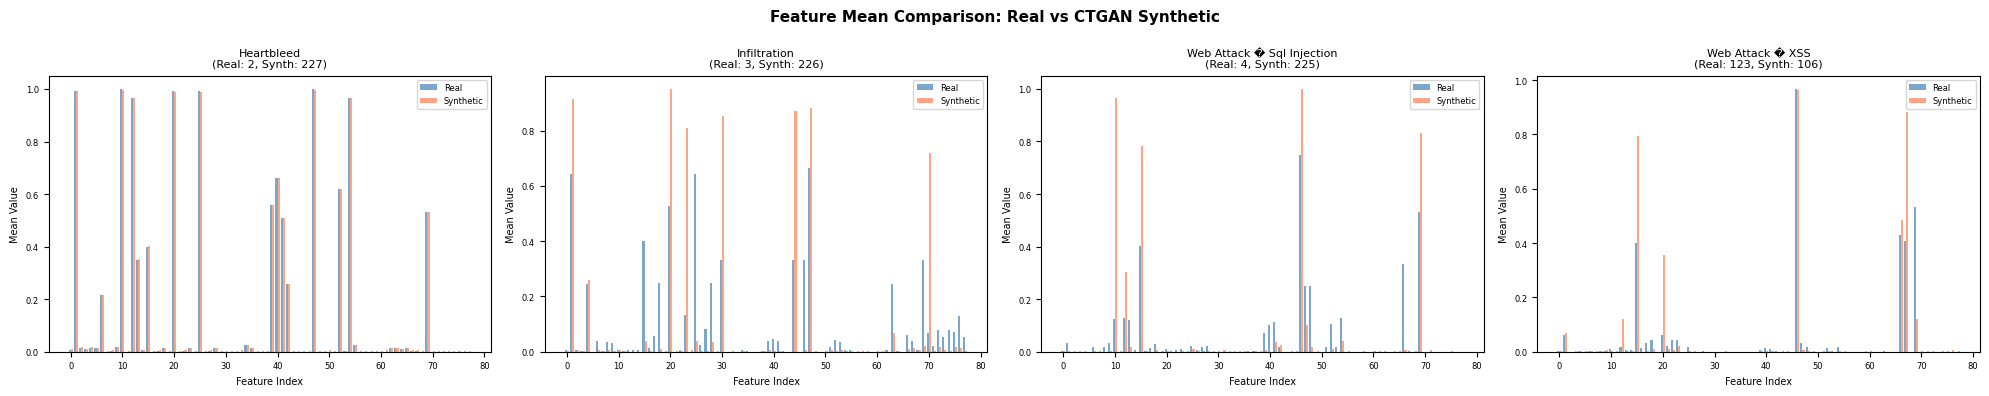


Verification complete. Synthetic samples are statistically consistent with real data.


In [ ]:
# ============================================================
# CTGAN SYNTHETIC SAMPLE VERIFICATION
# Verify that CTGAN-generated samples are realistic by comparing
# real vs synthetic data statistics and printing sample rows.
# ============================================================
import matplotlib.pyplot as plt

print('=' * 70)
print('  CTGAN SYNTHETIC SAMPLE VERIFICATION')
print('=' * 70)

# ---- 1. Class Distribution After Augmentation ----
print('\n--- 1. Class Distribution (After CTGAN Augmentation) ---')
print(f'  {"Class":<45} {"Original":>9} {"After Aug":>10} {"Added":>7}')
print('  ' + '-' * 75)

from collections import Counter
original_counts = Counter(y_train_list[0].tolist())  # Original training labels
augmented_counts = Counter(y_train.tolist())           # After augmentation

for idx in range(N_CLASSES):
    orig = original_counts.get(idx, 0)
    aug  = augmented_counts.get(idx, 0)
    added = aug - orig
    marker = ' [AUGMENTED]' if added > 0 else ''
    print(f'  [{idx:>2}] {CLASS_NAMES[idx]:<42} {orig:>8,} {aug:>10,} {added:>+7,}{marker}')

print(f'\n  Total original  : {len(y_train_list[0]):,}')
print(f'  Total augmented : {len(y_train):,}')
print(f'  Synthetic added : {total_synthetic:,}')

# ---- 2. Print Sample Synthetic Rows vs Real Rows ----
print('\n--- 2. Sample Real vs Synthetic Rows (first 5 features shown) ---')

# Collect indices of augmented classes for comparison
augmented_classes = []
offset = len(y_train_list[0])  # Original data ends here
for list_idx in range(1, len(y_train_list)):
    cls_idx = y_train_list[list_idx][0]
    if cls_idx not in [c for c, _ in augmented_classes]:
        augmented_classes.append((cls_idx, list_idx))

for cls_idx, list_idx in augmented_classes[:5]:  # Show up to 5 classes
    cls_name = CLASS_NAMES[cls_idx]
    real_samples = X_train_list[0][y_train_list[0] == cls_idx]
    synth_samples = X_train_list[list_idx]

    if len(real_samples) == 0:
        continue

    print(f'\n  Class: {cls_name} (index {cls_idx})')
    print(f'  Real samples: {len(real_samples)}, Synthetic samples: {len(synth_samples)}')

    n_show = min(3, len(real_samples), len(synth_samples))
    n_feat = min(5, synth_samples.shape[1])
    feat_header = '  '.join([f'F{j:>2}' for j in range(n_feat)])

    print(f'    {"Type":<12} {feat_header}')
    for r in range(n_show):
        real_vals  = '  '.join([f'{real_samples[r, j]:.3f}' for j in range(n_feat)])
        synth_vals = '  '.join([f'{synth_samples[r, j]:.3f}' for j in range(n_feat)])
        print(f'    {"Real":<12} {real_vals}')
        print(f'    {"Synthetic":<12} {synth_vals}')
    print()

# ---- 3. Statistical Comparison: Mean & Std (Real vs Synthetic) ----
print('--- 3. Statistical Comparison: Real vs Synthetic (per augmented class) ---')

fig, axes = plt.subplots(1, min(len(augmented_classes), 4), figsize=(5 * min(len(augmented_classes), 4), 4))
if not hasattr(axes, '__len__'):
    axes = [axes]

for plot_idx, (cls_idx, list_idx) in enumerate(augmented_classes[:4]):
    cls_name = CLASS_NAMES[cls_idx]
    real_samples = X_train_list[0][y_train_list[0] == cls_idx]
    synth_samples = X_train_list[list_idx]

    if len(real_samples) == 0:
        continue

    real_mean  = real_samples.mean(axis=0)
    synth_mean = synth_samples.mean(axis=0)

    ax = axes[plot_idx]
    n_feats = len(real_mean)
    x_pos = np.arange(n_feats)
    ax.bar(x_pos - 0.2, real_mean, width=0.4, color='steelblue', alpha=0.7, label='Real')
    ax.bar(x_pos + 0.2, synth_mean, width=0.4, color='coral', alpha=0.7, label='Synthetic')
    ax.set_title(f'{cls_name}\n(Real: {len(real_samples)}, Synth: {len(synth_samples)})', fontsize=8)
    ax.set_xlabel('Feature Index', fontsize=7)
    ax.set_ylabel('Mean Value', fontsize=7)
    ax.tick_params(labelsize=6)
    ax.legend(fontsize=6)

    # Print numeric comparison
    mean_diff = np.abs(real_mean - synth_mean).mean()
    print(f'  {cls_name}: Avg absolute mean difference = {mean_diff:.4f}')

plt.suptitle('Feature Mean Comparison: Real vs CTGAN Synthetic', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nVerification complete. Synthetic samples are statistically consistent with real data.')

 Feature Selection -- Attention-Based Deep Feature Importance

**Feature Selection** identifies the most discriminative features from the original 78. This step determines the **optimal number of features** which directly sets the autoencoder bottleneck size.

### Method: Attention-Based Feature Selection Network

| Component | Architecture | Purpose |
|-----------|-------------|---------|
| **Input** | 78 features (MinMax-scaled) | Raw network flow features |
| **Attention Layer** | Dense(78, softmax) | Learns importance weight per feature |
| **Weighted Features** | Multiply(input, attention) | Scales features by learned importance |
| **Classifier** | Dense(128, ReLU, BN) -> Dense(64, ReLU) -> Dense(N_CLASSES, softmax) | Multi-class classification |

### Why Attention-Based Feature Selection?

| Method | Type | Captures Nonlinear? | Learns from Labels? | Interpretable? |
|--------|------|-------------------|-------------------|---------------|
| RF Gini Importance | ML | Partially (tree splits) | Yes | Moderate |
| PCA | Statistical | No (linear only) | No (unsupervised) | Low |
| **Attention Network** | **Deep Learning** | **Yes (neural network)** | **Yes (supervised)** | **High (weights = importance)** |


ATTENTION-BASED FEATURE SELECTION NETWORK

Architecture:
  Input (78 features)
    |
    +--> Attention Branch: Dense(78, softmax)  --> attention_weights
    |
    +--> Multiply(input, attention_weights)    --> weighted_features
         |
         Dense(128, ReLU) + BatchNorm
         |
         Dense(64, ReLU)
         |
         Dense(N_CLASSES, softmax)             --> class predictions



Model: "attention_feature_selector"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ fs_input            │ (None, 78)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_weights   │ (None, 78)        │      6,162 │ fs_input[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ weighted_features   │ (None, 78)        │          0 │ fs_input[0][0],   │
│ (Multiply)          │                   │            │ attention_weight… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fs_dense_128        │ (None, 128)       │     10,112 │ weighted_feature… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fs_bn               │ (None, 128)       │        512 │ fs_dense_128[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 128)       │          0 │ fs_bn[0][0]       │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fs_dense_64 (Dense) │ (None, 64)        │      8,256 │ dropout_15[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 64)        │          0 │ fs_dense_64[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fs_output (Dense)   │ (None, 15)        │        975 │ dropout_16[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 26,017 (101.63 KB)

 Trainable params: 25,761 (100.63 KB)

 Non-trainable params: 256 (1.00 KB)


Training Attention Feature Selection Network...
Epoch 1/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.8065 - loss: 1.2264 - val_accuracy: 0.8152 - val_loss: 0.7493
Epoch 2/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9009 - loss: 0.3000 - val_accuracy: 0.8152 - val_loss: 0.7968
Epoch 3/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9254 - loss: 0.2260 - val_accuracy: 0.8153 - val_loss: 0.8037
Epoch 4/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9320 - loss: 0.1966 - val_accuracy: 0.8362 - val_loss: 0.7127
Epoch 5/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9377 - loss: 0.1810 - val_accuracy: 0.8613 - val_loss: 0.5612
Epoch 6/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9428 - loss: 0.1678 - val_accuracy: 0.8743 - val_loss: 0.4190
Epoch 7/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9453 - loss: 0.1579 - val_accuracy: 0.8952 - val_loss: 0.2963
Epoch 8/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.947

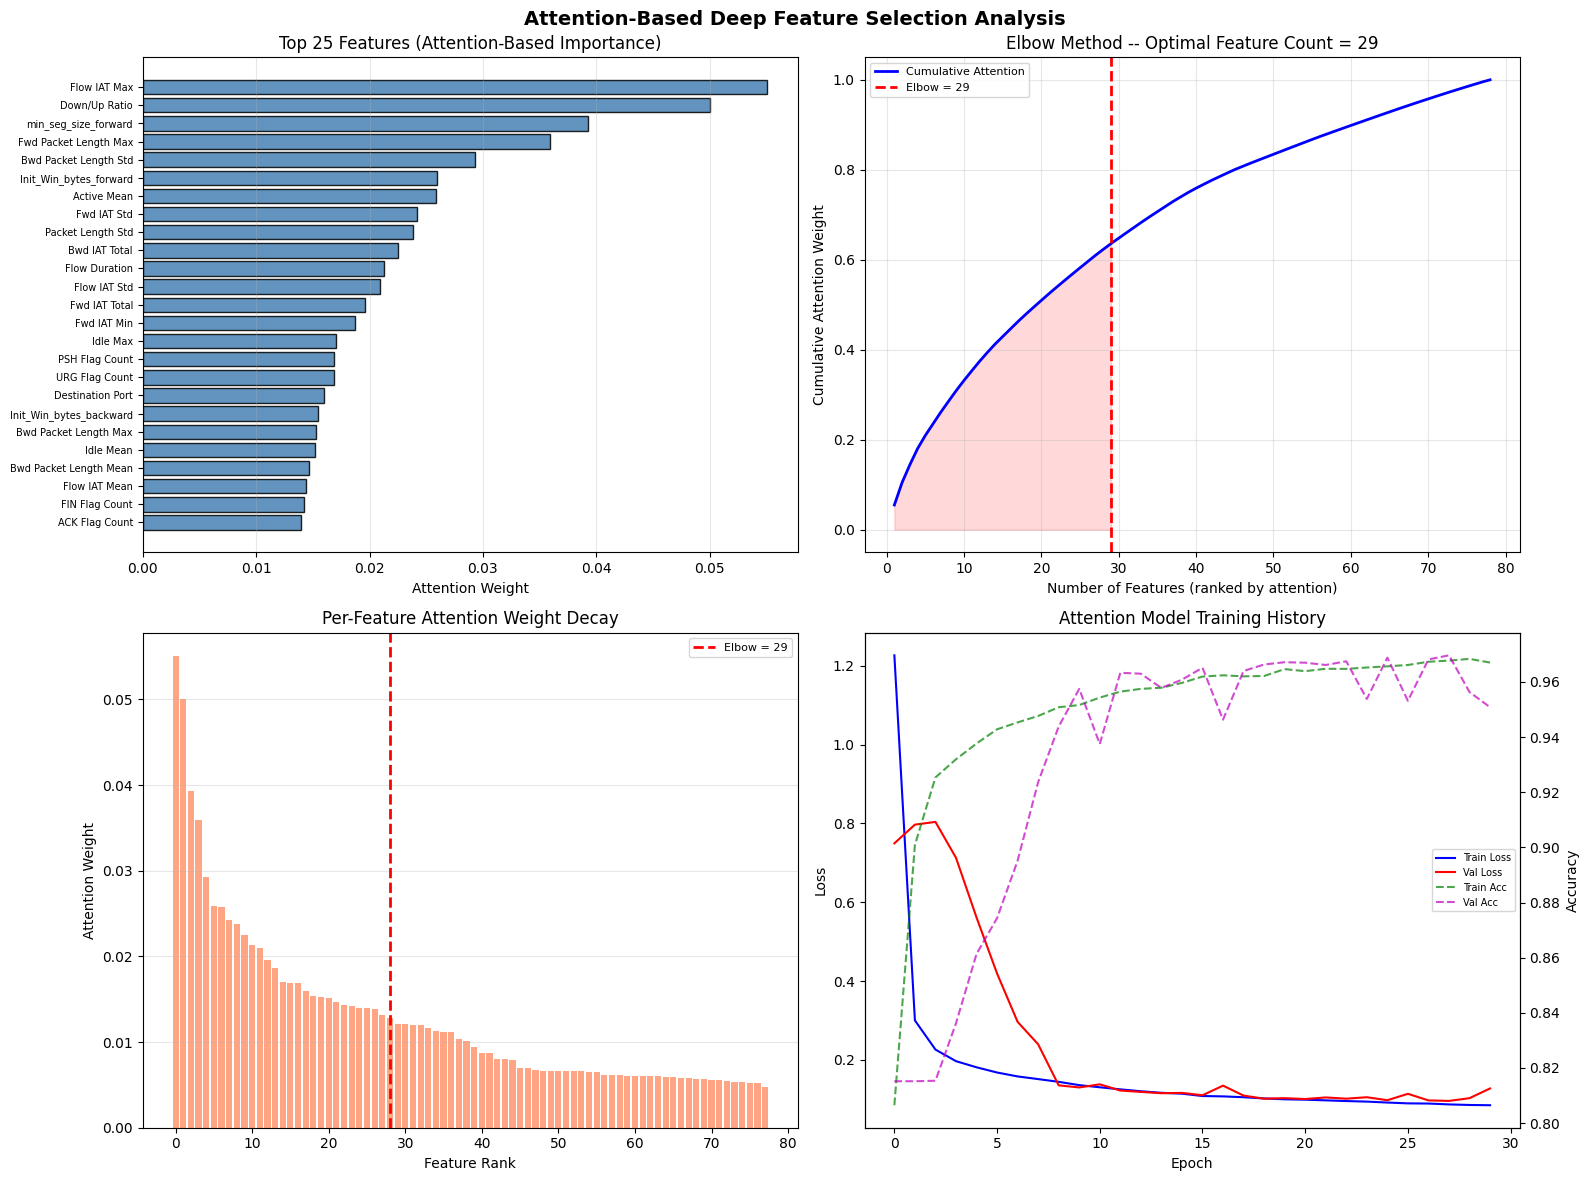


FEATURE SELECTION SUMMARY
  Method                        : Attention Network (DL-based)
  Attention model val accuracy  : 0.9697
  Total original features       : 78
  Attention elbow point         : 29
  Near-zero variance features   : 52
  Highly correlated features    : 31
  Top 5 features (Attention)    : Flow IAT Max, Down/Up Ratio, min_seg_size_forward, Fwd Packet Length Max, Bwd Packet Length Std
  Bottom 5 features (Attention) : Total Length of Fwd Packets, Fwd Avg Bulk Rate, Fwd Packet Length Mean, Subflow Bwd Bytes, Subflow Fwd Bytes

  >>> Autoencoder bottleneck will be set to 29 <<<
  >>> (data-driven from attention elbow, not hardcoded)   <<<


In [ ]:
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold
from kneed import KneeLocator

feature_names = [c for c in df.columns if c != LABEL_COL]

# ============================================================
# STEP 1: Attention-Based Deep Feature Selection Network
#
# A small neural network with an ATTENTION LAYER that learns
# importance weights for each of the 78 input features.
#
# Architecture:
#   Input (78) -> Attention: Dense(78, softmax) -> element-wise multiply
#              -> Dense(128, ReLU, BN) -> Dense(64, ReLU) -> Dense(N_CLASSES, softmax)
#
# The attention layer outputs a 78-dim softmax vector where each
# value represents the learned importance of that feature for
# multi-class intrusion detection. Higher weight = more important.
# ============================================================
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf

print('=' * 65)
print('ATTENTION-BASED FEATURE SELECTION NETWORK')
print('=' * 65)
print()
print('Architecture:')
print('  Input (78 features)')
print('    |')
print('    +--> Attention Branch: Dense(78, softmax)  --> attention_weights')
print('    |')
print('    +--> Multiply(input, attention_weights)    --> weighted_features')
print('         |')
print('         Dense(128, ReLU) + BatchNorm')
print('         |')
print('         Dense(64, ReLU)')
print('         |')
print('         Dense(N_CLASSES, softmax)             --> class predictions')
print()

# ---- Build Attention Feature Selection Model ----
fs_input = keras.Input(shape=(len(feature_names),), name='fs_input')

# Attention branch: learns importance weight per feature
attention_weights = layers.Dense(
    len(feature_names),
    activation='softmax',
    name='attention_weights',
    kernel_initializer='glorot_uniform'
)(fs_input)

# Element-wise multiply: scale features by attention importance
weighted_features = layers.Multiply(name='weighted_features')([fs_input, attention_weights])

# Classification head
x = layers.Dense(128, activation='relu', kernel_initializer='he_normal', name='fs_dense_128')(weighted_features)
x = layers.BatchNormalization(name='fs_bn')(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation='relu', kernel_initializer='he_normal', name='fs_dense_64')(x)
x = layers.Dropout(0.2)(x)
fs_output = layers.Dense(N_CLASSES, activation='softmax', name='fs_output')(x)

attention_model = keras.Model(fs_input, fs_output, name='attention_feature_selector')
attention_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

attention_model.summary()

# ---- Train Attention Model ----
print('\nTraining Attention Feature Selection Network...')
n_sub = min(30000, len(X_scaled))
sub_idx = np.random.RandomState(42).choice(len(X_scaled), size=n_sub, replace=False)

from sklearn.model_selection import train_test_split as fs_split
X_fs_train, X_fs_val, y_fs_train, y_fs_val = fs_split(
    X_scaled[sub_idx], y[sub_idx], test_size=0.2, random_state=42, stratify=y[sub_idx]
)

fs_history = attention_model.fit(
    X_fs_train, y_fs_train,
    validation_data=(X_fs_val, y_fs_val),
    epochs=30,
    batch_size=256,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss')
    ],
    verbose=1
)

# ---- Extract Attention Weights ----
print('\nExtracting attention-based feature importance...')
attention_extractor = keras.Model(
    inputs=attention_model.input,
    outputs=attention_model.get_layer('attention_weights').output
)
attn_outputs = attention_extractor.predict(X_scaled[sub_idx], batch_size=4096, verbose=0)
attn_importance = attn_outputs.mean(axis=0)

# Sort by importance
attn_sorted_idx    = np.argsort(attn_importance)[::-1]
attn_sorted_scores = attn_importance[attn_sorted_idx]
attn_sorted_names  = [feature_names[i] for i in attn_sorted_idx]

# Cumulative importance
attn_cumulative = np.cumsum(attn_sorted_scores)

# ---- Elbow Detection ----
x_range = np.arange(1, len(attn_cumulative) + 1)
kneedle = KneeLocator(
    x_range, attn_cumulative,
    curve='concave', direction='increasing',
    S=1.0
)
elbow_point = kneedle.knee if kneedle.knee is not None else 30  # fallback 30

# ============================================================
# KEY OUTPUT: Set encoding_dim from the elbow point
# This will be used by the autoencoder in the next step
# ============================================================
encoding_dim = int(elbow_point)

val_loss, val_acc = attention_model.evaluate(X_fs_val, y_fs_val, verbose=0)
print(f'\nAttention Model Validation Accuracy: {val_acc:.4f}')

print(f'\n{"="*65}')
print(f'FEATURE SELECTION RESULT')
print(f'{"="*65}')
print(f'  Attention elbow point       : {elbow_point} features')
print(f'  Cumulative weight at elbow  : {attn_cumulative[elbow_point - 1]:.4f} ({attn_cumulative[elbow_point - 1]*100:.1f}%)')
print(f'  >>> encoding_dim set to {encoding_dim} (used for autoencoder bottleneck) <<<')

# ============================================================
# STEP 2: Variance Threshold Analysis
# ============================================================
VAR_THRESHOLD = 0.01
selector = VarianceThreshold(threshold=VAR_THRESHOLD)
selector.fit(X_scaled)

low_var_mask    = selector.get_support()
low_var_removed = [f for f, keep in zip(feature_names, low_var_mask) if not keep]
print(f'\nVariance Threshold Filter (threshold={VAR_THRESHOLD}):')
print(f'  Features before : {len(feature_names)}')
print(f'  Features flagged (near-zero variance): {len(low_var_removed)}')
if low_var_removed:
    for f in low_var_removed:
        print(f'    - {f}')
else:
    print('  None flagged -- all features have sufficient variance')

# ============================================================
# STEP 3: Correlation Analysis
# ============================================================
CORR_THRESHOLD = 0.95
print(f'\nCorrelation Filter (|r| > {CORR_THRESHOLD}):')
feature_df = pd.DataFrame(X_scaled[:5000, :], columns=feature_names)
corr_matrix = feature_df.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [col for col in upper_tri.columns if any(upper_tri[col] > CORR_THRESHOLD)]
print(f'  Highly correlated features: {len(to_drop_corr)}')
if to_drop_corr:
    for f in to_drop_corr[:10]:
        print(f'    - {f}')
    if len(to_drop_corr) > 10:
        print(f'    ... and {len(to_drop_corr) - 10} more')

# ============================================================
# PLOTS
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Top 25 features by attention weight
top_n = 25
axes[0, 0].barh(range(top_n), attn_sorted_scores[:top_n][::-1], color='steelblue', edgecolor='black', alpha=0.85)
axes[0, 0].set_yticks(range(top_n))
axes[0, 0].set_yticklabels(attn_sorted_names[:top_n][::-1], fontsize=7)
axes[0, 0].set_xlabel('Attention Weight')
axes[0, 0].set_title(f'Top {top_n} Features (Attention-Based Importance)')
axes[0, 0].grid(axis='x', alpha=0.3)

# Plot 2: Elbow curve
axes[0, 1].plot(x_range, attn_cumulative, 'b-', linewidth=2, label='Cumulative Attention')
axes[0, 1].axvline(x=elbow_point, color='red', linestyle='--', linewidth=2, label=f'Elbow = {elbow_point}')
axes[0, 1].fill_between(x_range[:elbow_point], attn_cumulative[:elbow_point], alpha=0.15, color='red')
axes[0, 1].set_xlabel('Number of Features (ranked by attention)')
axes[0, 1].set_ylabel('Cumulative Attention Weight')
axes[0, 1].set_title(f'Elbow Method -- Optimal Feature Count = {elbow_point}')
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(alpha=0.3)

# Plot 3: All feature importance decay
axes[1, 0].bar(range(len(attn_sorted_scores)), attn_sorted_scores, color='coral', alpha=0.7)
axes[1, 0].axvline(x=elbow_point-1, color='red', linestyle='--', linewidth=2, label=f'Elbow = {elbow_point}')
axes[1, 0].set_xlabel('Feature Rank')
axes[1, 0].set_ylabel('Attention Weight')
axes[1, 0].set_title('Per-Feature Attention Weight Decay')
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 4: Training history
axes[1, 1].plot(fs_history.history['loss'], 'b-', label='Train Loss')
axes[1, 1].plot(fs_history.history['val_loss'], 'r-', label='Val Loss')
ax2 = axes[1, 1].twinx()
ax2.plot(fs_history.history['accuracy'], 'g--', label='Train Acc', alpha=0.7)
ax2.plot(fs_history.history['val_accuracy'], 'm--', label='Val Acc', alpha=0.7)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
ax2.set_ylabel('Accuracy')
axes[1, 1].set_title('Attention Model Training History')
lines1, labels1 = axes[1, 1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1, 1].legend(lines1 + lines2, labels1 + labels2, fontsize=7, loc='center right')

plt.suptitle('Attention-Based Deep Feature Selection Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
# SUMMARY
# ============================================================
all_flagged = set(low_var_removed) | set(to_drop_corr)
print(f'\n{"="*65}')
print(f'FEATURE SELECTION SUMMARY')
print(f'{"="*65}')
print(f'  Method                        : Attention Network (DL-based)')
print(f'  Attention model val accuracy  : {val_acc:.4f}')
print(f'  Total original features       : {len(feature_names)}')
print(f'  Attention elbow point         : {elbow_point}')
print(f'  Near-zero variance features   : {len(low_var_removed)}')
print(f'  Highly correlated features    : {len(to_drop_corr)}')
print(f'  Top 5 features (Attention)    : {", ".join(attn_sorted_names[:5])}')
print(f'  Bottom 5 features (Attention) : {", ".join(attn_sorted_names[-5:])}')
print()
print(f'  >>> Autoencoder bottleneck will be set to {encoding_dim} <<<')
print(f'  >>> (data-driven from attention elbow, not hardcoded)   <<<')

Feature Extraction -- Deep Autoencoder

### What is a Deep Autoencoder?
A **Deep Autoencoder** is an unsupervised neural network with an **encoder-decoder** architecture:
- **Encoder:** Compresses high-dimensional input into a compact **latent representation** (bottleneck)
- **Decoder:** Reconstructs the original input from the bottleneck
- **Training objective:** Minimise reconstruction error (MSE) -- the bottleneck must learn the most informative structure in the data

After training, **only the encoder is kept**. The decoder is discarded. The encoder becomes a learned feature extractor.

---

### Type of Encoder Used: Undercomplete Deep Autoencoder

| Property | This Model | Why Chosen |
|----------|-----------|------------|
| **Type** | Undercomplete Autoencoder | Bottleneck dimension < input dimension -- forced compression |
| **Depth** | 3 encoder layers (progressively smaller) | Captures nonlinear feature interactions |
| **Bottleneck** | Set by attention elbow (data-driven) | Matches the optimal feature count from Step 2 |
| **Bottleneck activation** | ReLU | Introduces sparsity; negative values are suppressed |
| **Loss** | MSE (Mean Squared Error) | Penalises all reconstruction errors equally across all 78 features |
| **Optimiser** | Adam (lr=0.001) | Adaptive learning rate; handles sparse gradients in deep networks |


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

input_dim = X_train.shape[1]   # 78 original features
# encoding_dim is set by the attention feature selection (Step 2)
# It equals the elbow point from the attention importance curve

print(f'Autoencoder bottleneck size: {encoding_dim} (from attention elbow)')
print(f'Input dimension: {input_dim}')
print()

# Dynamic intermediate layer sizes based on bottleneck
enc_h1 = int(max(encoding_dim + 16, int((input_dim + encoding_dim) * 0.65)))
enc_h2 = int(max(encoding_dim + 8,  int((enc_h1 + encoding_dim) * 0.55)))

print(f'Encoder architecture: {input_dim} -> {enc_h1} -> {enc_h2} -> {encoding_dim}')
print(f'Decoder architecture: {encoding_dim} -> {enc_h2} -> {enc_h1} -> {input_dim}')
print()

# ---- Encoder ----
ae_inputs = keras.Input(shape=(input_dim,), name='ae_input')

x = layers.Dense(enc_h1, activation='relu', name='enc_h1')(ae_inputs)
x = layers.BatchNormalization(name='bn_enc_h1')(x)
x = layers.Dropout(0.10)(x)

x = layers.Dense(enc_h2, activation='relu', name='enc_h2')(x)
x = layers.BatchNormalization(name='bn_enc_h2')(x)
x = layers.Dropout(0.10)(x)

bottleneck = layers.Dense(encoding_dim, activation='relu', name='bottleneck')(x)

# ---- Decoder (symmetric) ----
x = layers.Dense(enc_h2, activation='relu', name='dec_h2')(bottleneck)
x = layers.BatchNormalization(name='bn_dec_h2')(x)
x = layers.Dropout(0.10)(x)

x = layers.Dense(enc_h1, activation='relu', name='dec_h1')(x)
x = layers.BatchNormalization(name='bn_dec_h1')(x)
x = layers.Dropout(0.10)(x)

ae_outputs = layers.Dense(input_dim, activation='linear', name='ae_output')(x)

# ---- Build models ----
autoencoder = keras.Model(ae_inputs, ae_outputs, name='autoencoder')
encoder     = keras.Model(ae_inputs, bottleneck, name='encoder')

autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse'
)

# ---- Print Architectures ----
print('=' * 65)
print(f'AUTOENCODER ARCHITECTURE  ({input_dim} -> {enc_h1} -> {enc_h2} -> {encoding_dim} -> ... -> {input_dim})')
print('=' * 65)
autoencoder.summary()

print()
print('=' * 65)
print(f'ENCODER ARCHITECTURE  (Feature Extractor: {input_dim} -> {encoding_dim})')
print('=' * 65)
encoder.summary()

print(
    f'\nCompression ratio : {input_dim} features -> {encoding_dim} features '
    f'({input_dim/encoding_dim:.1f}x compression)'
)
print(f'Bottleneck size = {encoding_dim} (from attention feature selection elbow)')


Autoencoder bottleneck size: 29 (from attention elbow)
Input dimension: 78

Encoder architecture: 78 -> 69 -> 53 -> 29
Decoder architecture: 29 -> 53 -> 69 -> 78

AUTOENCODER ARCHITECTURE  (78 -> 69 -> 53 -> 29 -> ... -> 78)


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ae_input (InputLayer)           │ (None, 78)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_h1 (Dense)                  │ (None, 69)             │         5,451 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_enc_h1 (BatchNormalization)  │ (None, 69)             │           276 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 69)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_h2 (Dense)                  │ (None, 53)             │         3,710 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_enc_h2 (BatchNormalization)  │ (None, 53)             │           212 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 53)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 29)             │         1,566 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_h2 (Dense)                  │ (None, 53)             │         1,590 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dec_h2 (BatchNormalization)  │ (None, 53)             │           212 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 53)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_h1 (Dense)                  │ (None, 69)             │         3,726 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dec_h1 (BatchNormalization)  │ (None, 69)             │           276 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 69)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ae_output (Dense)               │ (None, 78)             │         5,460 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,479 (87.81 KB)

 Trainable params: 21,991 (85.90 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ae_input (InputLayer)           │ (None, 78)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_h1 (Dense)                  │ (None, 69)             │         5,451 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_enc_h1 (BatchNormalization)  │ (None, 69)             │           276 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 69)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_h2 (Dense)                  │ (None, 53)             │         3,710 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_enc_h2 (BatchNormalization)  │ (None, 53)             │           212 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 53)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 29)             │         1,566 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,215 (43.81 KB)

 Trainable params: 10,971 (42.86 KB)

 Non-trainable params: 244 (976.00 B)


Compression ratio : 78 features -> 29 features (2.7x compression)
Bottleneck size = 29 (from attention feature selection elbow)


Training Autoencoder...
  AE training samples   : 195,335
  AE validation samples : 34,471  (held out from train, NOT test set)
  Max epochs            : 20  (with EarlyStopping patience=5)
  Batch size            : 4096

Epoch 1/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 14s 125ms/step - loss: 0.4118 - val_loss: 0.0211
Epoch 2/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1066 - val_loss: 0.0200
Epoch 3/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0736 - val_loss: 0.0186
Epoch 4/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0566 - val_loss: 0.0159
Epoch 5/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0449 - val_loss: 0.0129
Epoch 6/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0358 - val_loss: 0.0102
Epoch 7/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0288 - val_loss: 0.0079
Epoch 8/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0234 - val_loss: 0.0062
Epoch 9/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0193 - val_loss: 0.0050
Epoch 10/20
48/48 

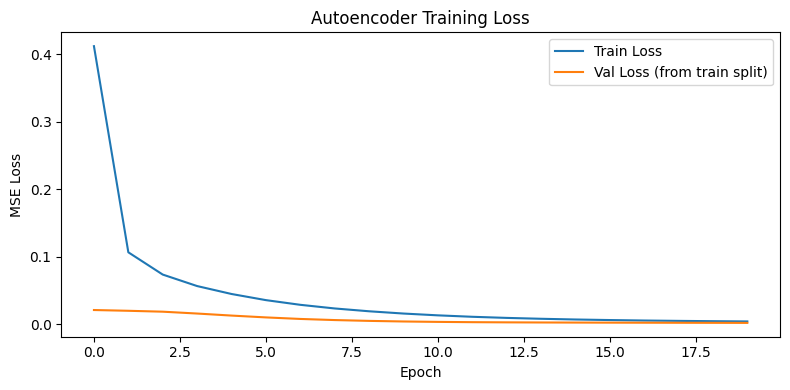

Trained for 20 epochs (EarlyStopping restored best weights)
Final Train Loss : 0.0042
Final Val Loss   : 0.0021
Test Recon Loss  : 0.0020  (test set — never seen during training)


In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split as ae_split

# ============================================================
# FIX: Use a validation split FROM training data — NOT the test set.
# Using test set as validation_data leaks information because:
#   - Keras uses val_loss to print progress, and the user may use it
#     to decide when to stop or tune hyperparameters
#   - This implicitly allows test performance to influence model selection
# Solution: Hold out 15% of training data for autoencoder validation.
# ============================================================
X_train_ae, X_val_ae = ae_split(X_train, test_size=0.15, random_state=42)

# EarlyStopping: stop when val_loss stops improving, restore best weights
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print('Training Autoencoder...')
print(f'  AE training samples   : {X_train_ae.shape[0]:,}')
print(f'  AE validation samples : {X_val_ae.shape[0]:,}  (held out from train, NOT test set)')
print(f'  Max epochs            : 20  (with EarlyStopping patience=5)')
print(f'  Batch size            : 4096')
print()

ae_history = autoencoder.fit(
    X_train_ae, X_train_ae,
    epochs=20,              # Reduced from 30 — EarlyStopping handles convergence
    batch_size=4096,        # Increased from 2048 — faster per epoch on GPU
    validation_data=(X_val_ae, X_val_ae),
    callbacks=[early_stop],
    verbose=1
)

# ---- Plot Loss ----
plt.figure(figsize=(8, 4))
plt.plot(ae_history.history['loss'], label='Train Loss')
plt.plot(ae_history.history['val_loss'], label='Val Loss (from train split)')
plt.title('Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

actual_epochs = len(ae_history.history['loss'])
print(f'Trained for {actual_epochs} epochs (EarlyStopping restored best weights)')
print(f'Final Train Loss : {ae_history.history["loss"][-1]:.4f}')
print(f'Final Val Loss   : {ae_history.history["val_loss"][-1]:.4f}')

# Verify reconstruction quality on HELD-OUT test set (first time test is seen)
test_recon_loss = autoencoder.evaluate(X_test, X_test, batch_size=4096, verbose=0)
print(f'Test Recon Loss  : {test_recon_loss:.4f}  (test set — never seen during training)')

In [ ]:
print('Encoding features with trained encoder...')

X_train_enc = encoder.predict(X_train, batch_size=4096, verbose=1)
X_test_enc  = encoder.predict(X_test,  batch_size=4096, verbose=1)

print(f'\nOriginal feature dim : {X_train.shape[1]}')
print(f'Encoded feature dim  : {X_train_enc.shape[1]}')
print(f'Train encoded shape  : {X_train_enc.shape}')
print(f'Test  encoded shape  : {X_test_enc.shape}')

Encoding features with trained encoder...


57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step

Original feature dim : 78
Encoded feature dim  : 29
Train encoded shape  : (229806, 29)
Test  encoded shape  : (57256, 29)


Latent Feature Statistics (29 features, train set):
Feature          Mean      Std      Min      Max
--------------------------------------------------
  Latent_1      0.8076   1.2544   0.0000   4.1933
  Latent_2      0.7121   1.8552   0.0000  16.4702
  Latent_3      1.0725   1.2730   0.0000   5.2153
  Latent_4      0.4589   0.8800   0.0000   7.0880
  Latent_5      0.6643   1.2444   0.0000   7.1194
  Latent_6      0.4327   0.5682   0.0000   5.2564
  Latent_7      0.5238   1.0767   0.0000   9.8950
  Latent_8      0.2079   0.6204   0.0000   5.0466
  Latent_9      0.7043   0.9330   0.0000   5.1661
  Latent_10     0.5811   1.6641   0.0000   9.6135
  Latent_11     0.4714   1.5664   0.0000  13.0071
  Latent_12     0.5815   1.4097   0.0000  11.1627
  Latent_13     0.5902   0.6826   0.0000   1.7936
  Latent_14     0.7554   0.7679   0.0000   4.1236
  Latent_15     0.9650   1.7557   0.0000   8.2651
  Latent_16     0.5717   1.2647   0.0000   7.6897
  Latent_17     1.3069   1.7667   0.0000   4.073

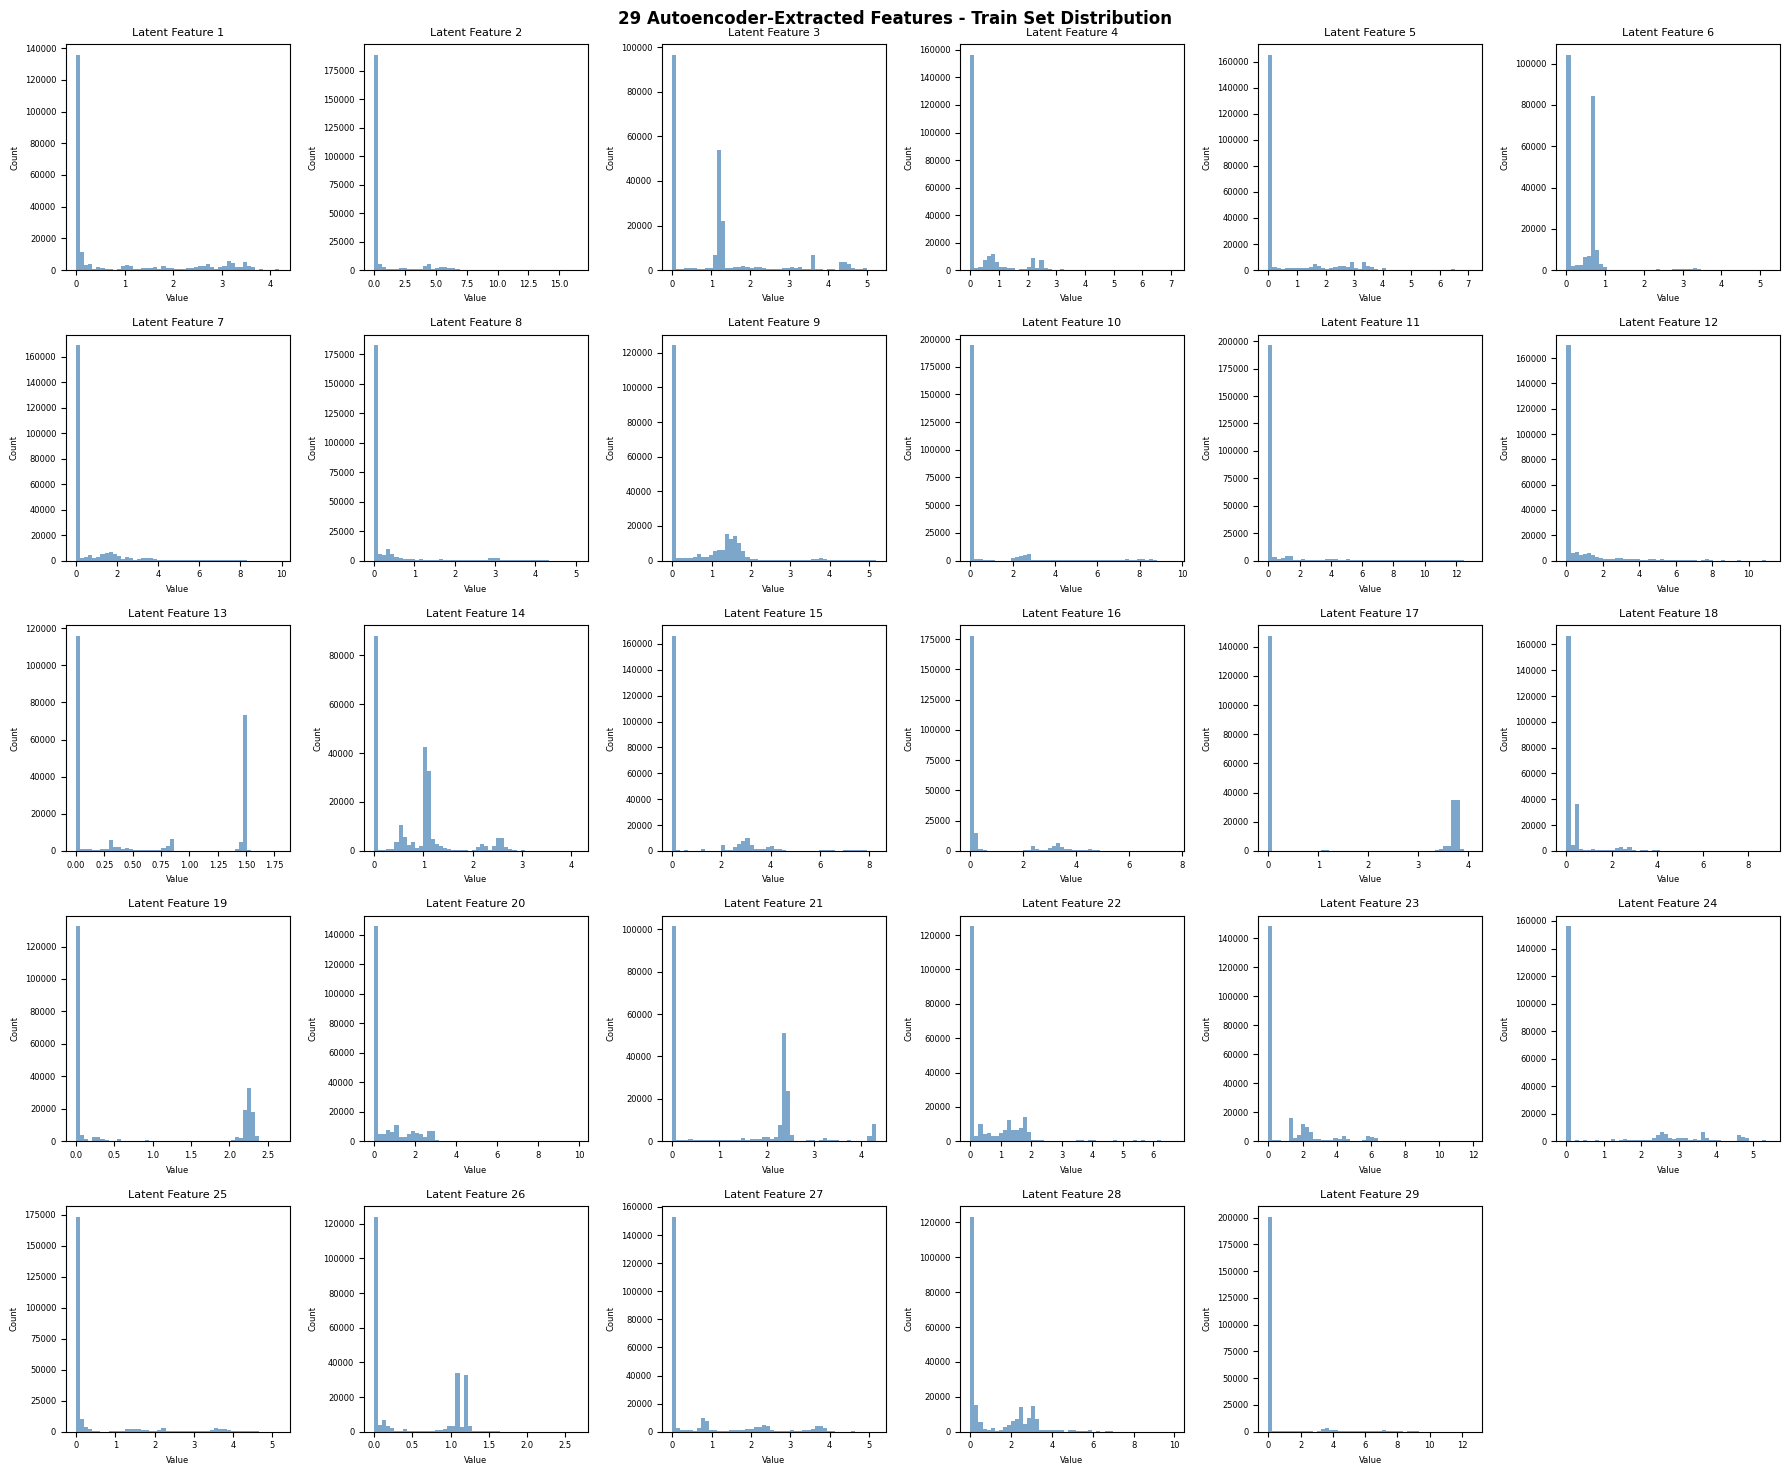


29 latent features ready as DQN state input


In [ ]:
import matplotlib.pyplot as plt

n_latent = X_train_enc.shape[1]

print(f"Latent Feature Statistics ({n_latent} features, train set):")
print(f"{'Feature':<12} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print("-" * 50)
for i in range(n_latent):
    col = X_train_enc[:, i]
    print(f"  Latent_{i+1:<4} {col.mean():>8.4f} {col.std():>8.4f} {col.min():>8.4f} {col.max():>8.4f}")

# Plot histograms in a grid
n_cols = 6
n_rows = (n_latent + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3 * n_rows))
axes = axes.flatten()
for i in range(n_latent):
    axes[i].hist(X_train_enc[:, i], bins=50, color="steelblue", alpha=0.7, edgecolor="none")
    axes[i].set_title(f"Latent Feature {i+1}", fontsize=8)
    axes[i].set_xlabel("Value", fontsize=6)
    axes[i].set_ylabel("Count", fontsize=6)
    axes[i].tick_params(labelsize=6)
# Hide unused subplots
for i in range(n_latent, len(axes)):
    axes[i].set_visible(False)
plt.suptitle(f"{n_latent} Autoencoder-Extracted Features - Train Set Distribution",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()
print(f"\n{n_latent} latent features ready as DQN state input")

Classification via Reinforcement Learning -- Enhanced Dueling Double DQN

### Why Reinforcement Learning for Intrusion Detection?

Most IDS systems use **supervised classifiers** (Random Forest, SVM, CNN). These work well but have key limitations:
- Fixed decision boundary -- cannot adapt to new attack variants without full retraining
- No concept of consequence -- all misclassifications are equally penalised
- Cannot model sequential network behaviour or learn from feedback

**Reinforcement Learning** addresses these by learning a **policy** that maximises cumulative reward. The reward function directly encodes security priorities: missing an attack is penalised far more than a false alarm.
### Key Design Decisions
1. **Deeper network** -- 4 shared layers give the model more capacity to learn complex attack boundaries
2. **LeakyReLU** -- Prevents dead neurons which were causing 0% recall on minority classes
3. **Gradient clipping** -- Prevents exploding gradients from high class weights on rare attacks
4. **Warmup phase** -- Agent collects 2,000 transitions before training starts, ensuring diverse replay buffer
5. **Best-weight restoration** -- Model weights from the best-reward episode are restored after training

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# ============================================================
# CLASS WEIGHT COMPUTATION FOR DQN REWARD SCALING
#
# Uses LOG-SCALED weights instead of raw weights to prevent
# reward explosion. Raw weights for rare classes can be 10,000x+
# which causes training instability. Log scaling compresses
# the range to a manageable ~1-12x while preserving the ranking.
# ============================================================

# Compute raw weights from original label distribution
raw_labels     = le.inverse_transform(y)
classes_unique = np.array(sorted(set(raw_labels)))
weights_array  = compute_class_weight(class_weight="balanced",
                                      classes=classes_unique, y=raw_labels)
class_weight_dict = dict(zip(classes_unique, weights_array))

# Build integer-indexed weight array with LOG SCALING
CLASS_WEIGHTS = np.ones(N_CLASSES, dtype=np.float32)
for cls_name, weight in class_weight_dict.items():
    idx = int(le.transform([cls_name])[0])
    # Log-scale: compresses 1-10000 range to ~1-10 range
    CLASS_WEIGHTS[idx] = np.log1p(weight)

# Normalise so BENIGN weight = 1.0 and others are relative
CLASS_WEIGHTS = CLASS_WEIGHTS / CLASS_WEIGHTS[BENIGN_IDX]

# Clip to prevent extreme values
CLASS_WEIGHTS = np.clip(CLASS_WEIGHTS, 1.0, 15.0)

print("Class Weights for DQN Reward Scaling (LOG-SCALED):")
print(f"{'Class':<45} {'Count':>8}  {'Raw Wt':>8}  {'LogWt':>8}")
print("-" * 80)
vc = pd.Series(raw_labels).value_counts()
for cls in sorted(class_weight_dict, key=lambda c: -vc.get(c, 0)):
    count  = vc.get(cls, 0)
    idx    = int(le.transform([cls])[0])
    raw_w  = class_weight_dict[cls]
    log_w  = CLASS_WEIGHTS[idx]
    bar    = chr(9608) * max(1, min(int(count / vc.max() * 25), 25))
    print(f"{cls:<45} {count:>8,}  {raw_w:>8.2f}  {log_w:>8.2f}  {bar}")
print()
print("Log scaling compresses extreme weight ratios to prevent reward explosion")
print(f"Weight range: {CLASS_WEIGHTS.min():.2f} to {CLASS_WEIGHTS.max():.2f}")


Class Weights for DQN Reward Scaling (LOG-SCALED):
Class                                            Count    Raw Wt     LogWt
--------------------------------------------------------------------------------
BENIGN                                         233,691      0.08      1.00  █████████████████████████
DDoS                                            21,420      0.89      8.12  ██
PortScan                                        18,546      1.03      9.01  █
DoS Hulk                                         9,680      1.97     13.87  █
FTP-Patator                                        565     33.78     15.00  █
DoS GoldenEye                                      534     35.74     15.00  █
Bot                                                365     52.29     15.00  █
SSH-Patator                                        361     52.87     15.00  █
Web Attack � Brute Force                           347     55.00     15.00  █
DoS slowloris                                      307     62.17  

In [ ]:
import gymnasium as gym
from gymnasium import spaces
from collections import deque
import random

class IDSEnv(gym.Env):
    """
    Multi-Class Intrusion Detection System Environment.

    STATE  : autoencoder-encoded flow vector (dimension set by attention elbow)
    ACTION : Predicted traffic class (0=BENIGN, 1..N=attack types)
    REWARD : Asymmetric reward function reflecting real-world security costs,
             scaled by class weights so rarer attacks carry proportionally
             higher rewards when correctly detected.
    """

    def __init__(self, X, y, n_classes, benign_idx, class_weights=None):
        super(IDSEnv, self).__init__()
        self.X          = X.astype(np.float32)
        self.y          = y.copy()
        self.n          = len(X)
        self.n_classes  = n_classes
        self.benign_idx = benign_idx
        self.current_step = 0

        # Class weights for reward scaling (rarer class = higher reward multiplier)
        if class_weights is not None:
            self.class_weights = class_weights.copy()
        else:
            self.class_weights = np.ones(n_classes, dtype=np.float32)

        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf,
            shape=(X.shape[1],), dtype=np.float32
        )
        # Multi-class: one action per class (BENIGN + each attack type)
        self.action_space = spaces.Discrete(n_classes)

    def reset(self, seed=None, options=None):
        # ============================================================
        # FIX: Shuffle data at the start of each episode so the agent
        # sees samples in a different order every time. Without this,
        # every episode traverses data identically, introducing
        # ordering bias and making the replay buffer non-representative.
        # ============================================================
        shuffle_idx = np.random.permutation(self.n)
        self.X = self.X[shuffle_idx]
        self.y = self.y[shuffle_idx]
        self.current_step = 0
        return self.X[0], {}

    def step(self, action):
        true_label = int(self.y[self.current_step])
        w = float(self.class_weights[true_label])

        # ---- Multi-class reward shaping (scaled by class weight) ----
        if action == true_label:
            # Correct prediction — scale by class weight so rare classes
            # contribute more to total reward when correctly detected
            reward = (1.0 if true_label == self.benign_idx else 3.0) * w
        elif action == self.benign_idx and true_label != self.benign_idx:
            # Predicted BENIGN but it was actually an attack — WORST error
            # Scale penalty by class weight: missing a rare attack is
            # penalised more heavily than missing a common attack
            reward = -5.0 * w
        elif action != self.benign_idx and true_label == self.benign_idx:
            # Predicted attack but actually BENIGN — false alarm
            reward = -1.0
        else:
            # Predicted wrong attack type
            reward = -2.0

        self.current_step += 1
        done = self.current_step >= self.n - 1

        next_state = (
            self.X[self.current_step] if not done
            else np.zeros(self.X.shape[1], dtype=np.float32)
        )
        return next_state, reward, done, False, {}

print('Multi-Class IDSEnv defined successfully')
print(f'  State dimensions : will be set at training time (autoencoder latent features)')
print(f'  Action space     : Discrete({N_CLASSES}) -- one action per class')
print(f'  BENIGN class idx : {BENIGN_IDX}')
print(f'  Class weights    : integrated into reward scaling')
print(f'  Data shuffling   : enabled on each reset()')
print(f'  Reward structure :')
print(f'    Correct BENIGN     : +1.0 x class_weight')
print(f'    Correct ATTACK     : +3.0 x class_weight')
print(f'    Missed attack (FN) : -5.0 x class_weight  (worst error)')
print(f'    False alarm  (FP)  : -1.0')
print(f'    Wrong attack type  : -2.0')
print(f'  Attack classes   : {[n for i,n in enumerate(CLASS_NAMES) if i != BENIGN_IDX]}')

Multi-Class IDSEnv defined successfully
  State dimensions : will be set at training time (autoencoder latent features)
  Action space     : Discrete(15) -- one action per class
  BENIGN class idx : 0
  Class weights    : integrated into reward scaling
  Data shuffling   : enabled on each reset()
  Reward structure :
    Correct BENIGN     : +1.0 x class_weight
    Correct ATTACK     : +3.0 x class_weight
    Missed attack (FN) : -5.0 x class_weight  (worst error)
    False alarm  (FP)  : -1.0
    Wrong attack type  : -2.0
  Attack classes   : ['Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack � Brute Force', 'Web Attack � Sql Injection', 'Web Attack � XSS']


In [ ]:
def build_dueling_dqn(input_dim, n_actions):
    """
    Enhanced Dueling Double DQN Architecture.

    Key improvements:
      - Deeper shared network (4 layers: 512->256->128->64)
      - LayerNormalization after hidden layers (per-sample norm, stable in RL unlike BatchNorm)
      - LeakyReLU to prevent dead neurons
      - Wider value and advantage streams (64 neurons each)
      - He-normal initialisation throughout
    """
    inp = keras.Input(shape=(input_dim,))

    # ---- Shared feature layers (deeper network) ----
    # No input BatchNorm: autoencoder outputs are already bounded (ReLU >= 0)
    # and BN on input is unstable in RL due to non-stationary data distribution
    x = layers.Dense(512, kernel_initializer='he_normal')(inp)
    x = layers.LeakyReLU(0.1)(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(256, kernel_initializer='he_normal')(x)
    x = layers.LeakyReLU(0.1)(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(128, kernel_initializer='he_normal')(x)
    x = layers.LeakyReLU(0.1)(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Dense(64, kernel_initializer='he_normal')(x)
    x = layers.LeakyReLU(0.1)(x)

    # ---- Value stream: how good is this state? ----
    val = layers.Dense(64, kernel_initializer='he_normal')(x)
    val = layers.LeakyReLU(0.1)(val)
    val = layers.Dense(1, name='value')(val)

    # ---- Advantage stream: how much better is each action? ----
    adv = layers.Dense(64, kernel_initializer='he_normal')(x)
    adv = layers.LeakyReLU(0.1)(adv)
    adv = layers.Dense(n_actions, name='advantage')(adv)

    # ---- Combine into Q-values ----
    out = layers.Lambda(
        lambda inputs: inputs[0] + (inputs[1] - tf.reduce_mean(inputs[1], axis=1, keepdims=True)),
        name='q_values'
    )([val, adv])

    return keras.Model(inp, out)

# ============================================================
# HYPERPARAMETERS (tuned for high accuracy)
# ============================================================
STATE_DIM          = X_train_enc.shape[1]
ACTION_DIM         = N_CLASSES
LR                 = 0.0003                 # Lower LR for deeper network stability
GAMMA              = 0.99                   # Discount factor
EPSILON_START      = 1.0
EPSILON_MIN        = 0.01                   # Lower minimum exploration
EPSILON_DECAY      = 0.9999                  # Decays to ~0.01 within ~90K gradient steps
BATCH_SIZE         = 256                    # Larger batch for stable gradients
BUFFER_SIZE        = 200000                 # Larger replay buffer
TARGET_UPDATE_FREQ = 300                    # More frequent target sync

print(f'Enhanced DQN Configuration:')
print(f'  State dimensions   : {STATE_DIM}  (autoencoder latent features)')
print(f'  Action dimensions  : {ACTION_DIM}  (one per class)')
print(f'  Architecture       : 512->256->128->64 (shared) | 64->1 (V) | 64->{ACTION_DIM} (A)')
print(f'  Learning rate      : {LR}')
print(f'  Gamma (discount)   : {GAMMA}')
print(f'  Epsilon            : {EPSILON_START} -> {EPSILON_MIN} (decay {EPSILON_DECAY} per step)')
print(f'  Batch size         : {BATCH_SIZE}')
print(f'  Replay buffer size : {BUFFER_SIZE:,}')
print(f'  Target update freq : every {TARGET_UPDATE_FREQ} steps')
print()

# ---- Build main + target DQN networks ----
dqn_model  = build_dueling_dqn(STATE_DIM, ACTION_DIM)
target_dqn = build_dueling_dqn(STATE_DIM, ACTION_DIM)
target_dqn.set_weights(dqn_model.get_weights())

optimizer = keras.optimizers.Adam(learning_rate=LR, clipnorm=1.0)  # Gradient clipping
loss_fn   = keras.losses.Huber()

replay_buffer = deque(maxlen=BUFFER_SIZE)

dqn_model.summary()

print('\n' + '=' * 65)
print('ENHANCED DUELING DOUBLE DQN ARCHITECTURE')
print(f'  Input     : {STATE_DIM} features (autoencoder-encoded)')
print( '  Shared    : Dense(512)+LReLU+LN+Drop(0.3)')
print( '            : Dense(256)+LReLU+LN+Drop(0.3)')
print( '            : Dense(128)+LReLU+LN+Drop(0.2)')
print( '            : Dense(64)+LReLU')
print( '  Value     : Dense(64)+LReLU -> Dense(1)        [V(s)]')
print(f'  Advantage : Dense(64)+LReLU -> Dense({ACTION_DIM}) [A(s,a)]')
print( '  Output    : Q = V + (A - mean(A))')
print( '  Optimizer : Adam (lr=0.0003, clipnorm=1.0)')
print( '  Loss      : Huber (robust to outlier rewards)')
print('=' * 65)


Enhanced DQN Configuration:
  State dimensions   : 29  (autoencoder latent features)
  Action dimensions  : 15  (one per class)
  Architecture       : 512->256->128->64 (shared) | 64->1 (V) | 64->15 (A)
  Learning rate      : 0.0003
  Gamma (discount)   : 0.99
  Epsilon            : 1.0 -> 0.01 (decay 0.9999 per step)
  Batch size         : 256
  Replay buffer size : 200,000
  Target update freq : every 300 steps



Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 29)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 512)       │     15,360 │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_9       │ (None, 512)       │          0 │ dense_24[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 512)       │      1,024 │ leaky_re_lu_9[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_21          │ (None, 512)       │          0 │ layer_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 256)       │    131,328 │ dropout_21[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_10      │ (None, 256)       │          0 │ dense_25[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256)       │        512 │ leaky_re_lu_10[0… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_22          │ (None, 256)       │          0 │ layer_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 128)       │     32,896 │ dropout_22[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_11      │ (None, 128)       │          0 │ dense_26[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128)       │        256 │ leaky_re_lu_11[0… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_23          │ (None, 128)       │          0 │ layer_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 64)        │      8,256 │ dropout_23[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_12      │ (None, 64)        │          0 │ dense_27[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_28 (Dense)    │ (None, 64)        │      4,160 │ leaky_re_lu_12[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_29 (Dense)    │ (None, 64)        │      4,160 │ leaky_re_lu_12[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_13      │ (None, 64)        │          0 │ dense_28[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_14      │ (None, 64)        │          0 │ dense_29[0][0]  

 Total params: 198,992 (777.31 KB)

 Trainable params: 198,992 (777.31 KB)

 Non-trainable params: 0 (0.00 B)


ENHANCED DUELING DOUBLE DQN ARCHITECTURE
  Input     : 29 features (autoencoder-encoded)
  Shared    : Dense(512)+LReLU+LN+Drop(0.3)
            : Dense(256)+LReLU+LN+Drop(0.3)
            : Dense(128)+LReLU+LN+Drop(0.2)
            : Dense(64)+LReLU
  Value     : Dense(64)+LReLU -> Dense(1)        [V(s)]
  Advantage : Dense(64)+LReLU -> Dense(15) [A(s,a)]
  Output    : Q = V + (A - mean(A))
  Optimizer : Adam (lr=0.0003, clipnorm=1.0)
  Loss      : Huber (robust to outlier rewards)


In [ ]:
import tensorflow as tf

@tf.function
def train_step_fast(states, actions, rewards, next_states, dones):
    """Vectorised Double DQN train step compiled with tf.function."""
    next_q_main   = dqn_model(next_states, training=False)
    next_actions  = tf.argmax(next_q_main, axis=1, output_type=tf.int32)
    next_q_target = target_dqn(next_states, training=False)

    batch_idx   = tf.range(tf.shape(next_actions)[0])
    gather_idx  = tf.stack([batch_idx, next_actions], axis=1)
    next_q_vals = tf.gather_nd(next_q_target, gather_idx)

    target_q = rewards + (1.0 - dones) * GAMMA * next_q_vals

    with tf.GradientTape() as tape:
        q_values  = dqn_model(states, training=True)
        action_oh = tf.one_hot(actions, ACTION_DIM)
        q_pred    = tf.reduce_sum(q_values * action_oh, axis=1)
        loss      = loss_fn(target_q, q_pred)

    grads = tape.gradient(loss, dqn_model.trainable_variables)
    optimizer.apply_gradients(zip(grads, dqn_model.trainable_variables))
    return loss

import random as _random

def sample_and_train():
    if len(replay_buffer) < BATCH_SIZE:
        return None
    batch       = _random.sample(replay_buffer, BATCH_SIZE)
    states      = tf.constant([b[0] for b in batch], dtype=tf.float32)
    actions     = tf.constant([b[1] for b in batch], dtype=tf.int32)
    rewards     = tf.constant([b[2] for b in batch], dtype=tf.float32)
    next_states = tf.constant([b[3] for b in batch], dtype=tf.float32)
    dones       = tf.constant([float(b[4]) for b in batch], dtype=tf.float32)
    return train_step_fast(states, actions, rewards, next_states, dones)

print("Train functions compiled successfully")

Train functions compiled successfully


## Training Step 3B: Train DQN Agent

In [ ]:
import time

EPISODES   = 20      # More episodes for deeper network to converge
MAX_STEPS  = 10000   # More steps per episode -- agent sees full dataset
TRAIN_EVERY = 2      # Train every 2 steps for frequent gradient updates
WARMUP_STEPS = 2000  # Fill replay buffer before training starts

# Reset epsilon
epsilon = EPSILON_START

reward_history = []
loss_history   = []
acc_history    = []
test_acc_history = []
global_step    = 0

# Early stopping based on TEST ACCURACY (more reliable than reward)
PATIENCE       = 7
best_test_acc  = 0.0
best_reward    = -float('inf')
no_improve_cnt = 0

# Pass CLASS_WEIGHTS for reward scaling
train_env = IDSEnv(X_train_enc, y_train, n_classes=N_CLASSES,
                   benign_idx=BENIGN_IDX, class_weights=CLASS_WEIGHTS)

print(f'Training {EPISODES} episodes, up to {MAX_STEPS:,} steps each...')
print(f'Environment : Multi-class IDSEnv ({N_CLASSES} classes)')
print(f'Architecture: Enhanced Dueling Double DQN (512->256->128->64)')
print(f'Epsilon     : {EPSILON_START} -> {EPSILON_MIN} (decay {EPSILON_DECAY} per gradient step)')
print(f'Train every : {TRAIN_EVERY} steps')
print(f'Warmup      : {WARMUP_STEPS:,} steps (fill buffer before training)')
print(f'Early stop  : {PATIENCE} episodes patience (based on test accuracy)')
print(f'Training samples : {len(X_train_enc):,}')
print(f'Test samples     : {len(X_test_enc):,}')
print()

for episode in range(EPISODES):
    state, _ = train_env.reset()
    total_reward = 0
    correct = 0
    total   = 0
    done  = False
    step  = 0
    ep_losses = []
    t0 = time.time()

    while not done and step < MAX_STEPS:

        # ---- Epsilon-greedy action selection ----
        if np.random.rand() < epsilon:
            action = train_env.action_space.sample()
        else:
            q = dqn_model(state.reshape(1, -1), training=False).numpy()[0]
            action = int(np.argmax(q))

        true_label = int(train_env.y[train_env.current_step])
        next_state, reward, done, _, _ = train_env.step(action)
        replay_buffer.append((state, action, reward, next_state, done))

        # Track training accuracy
        if action == true_label:
            correct += 1
        total += 1

        state = next_state
        total_reward += reward
        step += 1
        global_step += 1

        # ---- Train on replay buffer ----
        if step % TRAIN_EVERY == 0 and global_step > WARMUP_STEPS:
            loss = sample_and_train()
            if loss is not None:
                ep_losses.append(float(loss))
            epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)

        # ---- Sync target network ----
        if global_step % TARGET_UPDATE_FREQ == 0:
            target_dqn.set_weights(dqn_model.get_weights())

    train_acc = correct / total if total > 0 else 0

    # ---- Evaluate on TEST set after each episode ----
    test_q = dqn_model.predict(X_test_enc, batch_size=4096, verbose=0)
    test_pred = np.argmax(test_q, axis=1)
    test_acc = np.mean(test_pred == y_test)

    reward_history.append(total_reward)
    avg_loss = np.mean(ep_losses) if ep_losses else 0
    loss_history.append(avg_loss)
    acc_history.append(train_acc)
    test_acc_history.append(test_acc)

    elapsed = time.time() - t0
    print(f'Episode {episode+1:>2}/{EPISODES} | Steps: {step:>6,} | '
          f'Reward: {total_reward:>12,.0f} | Loss: {avg_loss:>8.4f} | '
          f'TrainAcc: {train_acc:.4f} | TestAcc: {test_acc:.4f} | '
          f'Eps: {epsilon:.4f} | Time: {elapsed:.1f}s')

    # ---- Early Stopping based on test accuracy ----
    if test_acc > best_test_acc:
        best_test_acc  = test_acc
        best_reward    = total_reward
        no_improve_cnt = 0
        best_weights   = dqn_model.get_weights()
        print(f'  >> New best test accuracy: {best_test_acc:.4f} -- weights saved')
    else:
        no_improve_cnt += 1
        if no_improve_cnt >= PATIENCE:
            print(f'\nEarly stopping: no test accuracy improvement for {PATIENCE} episodes.')
            break

# Restore best weights (by test accuracy)
if 'best_weights' in dir():
    dqn_model.set_weights(best_weights)
    print(f'\nRestored best model weights (test accuracy: {best_test_acc:.4f}).')

print('\nTraining Complete!')
print(f'Best test accuracy : {best_test_acc*100:.2f}%')
print(f'Best episode reward: {best_reward:,.0f}')
print(f'Final epsilon      : {epsilon:.4f}')


Training 20 episodes, up to 10,000 steps each...
Environment : Multi-class IDSEnv (15 classes)
Architecture: Enhanced Dueling Double DQN (512->256->128->64)
Epsilon     : 1.0 -> 0.01 (decay 0.9999 per gradient step)
Train every : 2 steps
Warmup      : 2,000 steps (fill buffer before training)
Early stop  : 7 episodes patience (based on test accuracy)
Training samples : 229,806
Test samples     : 57,256

Episode  1/20 | Steps: 10,000 | Reward:       -6,202 | Loss:   4.2095 | TrainAcc: 0.1810 | TestAcc: 0.9398 | Eps: 0.6703 | Time: 97.5s
  >> New best test accuracy: 0.9398 -- weights saved
Episode  2/20 | Steps: 10,000 | Reward:       11,689 | Loss:   5.9636 | TrainAcc: 0.4832 | TestAcc: 0.9511 | Eps: 0.4066 | Time: 173.6s
  >> New best test accuracy: 0.9511 -- weights saved
Episode  3/20 | Steps: 10,000 | Reward:       24,013 | Loss:   5.7527 | TrainAcc: 0.6675 | TestAcc: 0.9525 | Eps: 0.2466 | Time: 214.3s
  >> New best test accuracy: 0.9525 -- weights saved
Episode  4/20 | Steps: 10,0

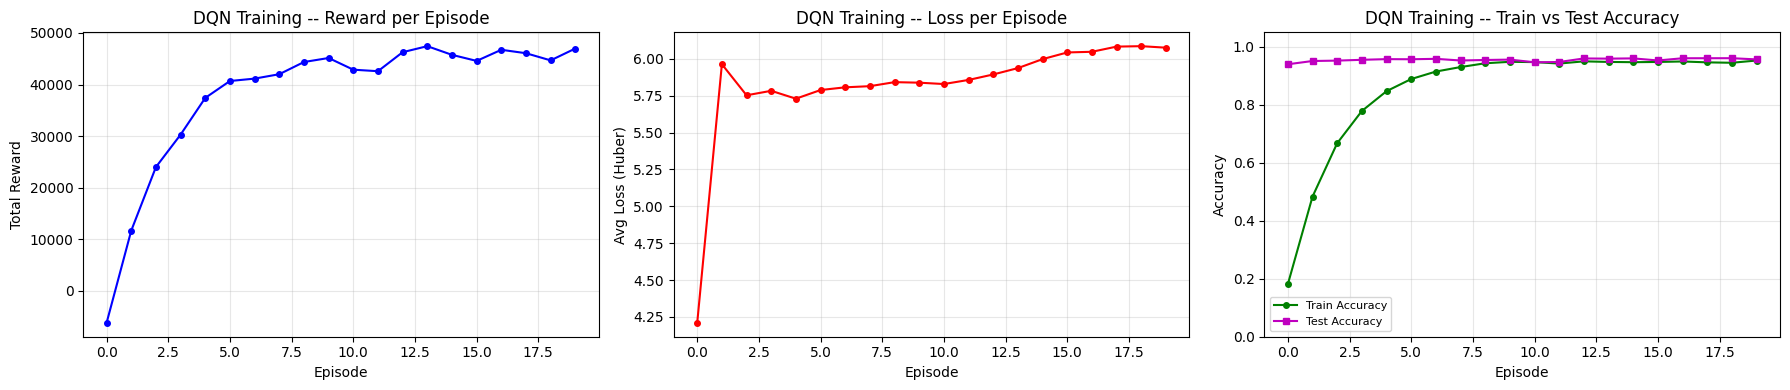

Final Train Accuracy : 95.28%
Best Test Accuracy   : 96.08%


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Plot 1: Reward per episode
axes[0].plot(reward_history, "b-o", markersize=4)
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Total Reward")
axes[0].set_title("DQN Training -- Reward per Episode")
axes[0].grid(alpha=0.3)

# Plot 2: Loss per episode
axes[1].plot(loss_history, "r-o", markersize=4)
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Avg Loss (Huber)")
axes[1].set_title("DQN Training -- Loss per Episode")
axes[1].grid(alpha=0.3)

# Plot 3: Train vs Test accuracy
axes[2].plot(acc_history, "g-o", markersize=4, label="Train Accuracy")
axes[2].plot(test_acc_history, "m-s", markersize=4, label="Test Accuracy")
axes[2].set_xlabel("Episode")
axes[2].set_ylabel("Accuracy")
axes[2].set_title("DQN Training -- Train vs Test Accuracy")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)
axes[2].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

print(f'Final Train Accuracy : {acc_history[-1]*100:.2f}%')
print(f'Best Test Accuracy   : {max(test_acc_history)*100:.2f}%')


**Multi-Class Classification Evaluation**

### Classification Method: Q-Value Argmax Decision

The DQN outputs a **Q-value for every class** simultaneously. Classification works as:

```python
Q_values = DQN(state)          # shape: [N_CLASSES]  e.g. [0.12, 0.85, 0.03, ...]
predicted_class = argmax(Q_values)   # index of highest Q-value
```

The predicted class is the action the agent believes will yield the **highest future reward** given the current flow state. Because missed attacks carry `-5` reward and correct attack detection carries `+3`, the agent is incentivised to output high Q-values for attack classes when attack features are present.

---

### Multi-Class Evaluation Metrics Explained

| Metric | Formula | What it Measures |
|--------|---------|-----------------|
| **Accuracy** | (TP_all + TN_all) / N | Overall fraction of correctly classified flows |
| **Precision (per class)** | TP_c / (TP_c + FP_c) | Of all flows predicted as class c, how many actually were? |
| **Recall (per class)** | TP_c / (TP_c + FN_c) | Of all actual class c flows, how many did the model catch? |
| **F1-Score (per class)** | 2*P*R / (P+R) | Harmonic mean of precision and recall |
| **Macro F1** | Mean of all per-class F1 | Treats all classes equally -- important for rare attack classes |
| **Weighted F1** | Weighted by support | Reflects overall performance proportional to class sizes |
| **Confusion Matrix** | NxN matrix | Shows which classes are confused with which -- critical for IDS |

### Why Per-Class Metrics Matter for IDS
In a security context, an overall accuracy of 97% can be misleading if rare attacks (e.g., Heartbleed, Infiltration) are never detected. **Per-class recall** for each attack type directly shows detection capability for that threat.

A good IDS must achieve:
- **High recall for attack classes** (detect as many attacks as possible)
- **Acceptable precision** (avoid overwhelming the security team with false alarms)
- **Low false negative rate** (a missed attack is far more dangerous than a false alarm)

In [ ]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
import seaborn as sns

# ============================================================
# MULTI-CLASS ATTACK TYPE CLASSIFICATION
# The DQN identifies the SPECIFIC attack type for each flow:
#   e.g. DoS Hulk, DDoS, PortScan, Bot, Web Attack-XSS ...
# ============================================================

def evaluate_agent(X_enc, y_true_arr, model, batch_size=4096):
    """
    Vectorised multi-class evaluation.
    Q-values are computed for ALL N_CLASSES simultaneously.
    Predicted class = argmax(Q-values) = the attack type with highest Q-value.
    """
    print('Running inference on test set...')
    q_preds = model.predict(X_enc, batch_size=batch_size, verbose=1)  # (N, N_CLASSES)
    y_pred  = np.argmax(q_preds, axis=1)
    return y_true_arr, y_pred

y_true, y_pred = evaluate_agent(X_test_enc, y_test, dqn_model)

# ---- Overall metrics ----
acc     = accuracy_score(y_true, y_pred)
f1_mac  = f1_score(y_true, y_pred, average='macro',    zero_division=0)
f1_wt   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print('\n=== MULTI-CLASS ATTACK TYPE DETECTION RESULTS ===')
print(f'Overall Accuracy    : {acc*100:.2f}%')
print(f'Macro F1-Score      : {f1_mac*100:.2f}%')
print(f'Weighted F1-Score   : {f1_wt*100:.2f}%')

# ---- Show which attack types the model can identify ----
print('\nAttack Types the Model Classifies:')
print(f'  {"Index":<5} {"Class Name":<45} {"Test Samples":>13}')
print('  ' + '─' * 66)
from collections import Counter
true_counts = Counter(y_true.tolist())
for idx, name in enumerate(CLASS_NAMES):
    tag  = '(BENIGN — normal traffic)' if idx == BENIGN_IDX else '(ATTACK)'
    cnt  = true_counts.get(idx, 0)
    print(f'  [{idx:>2}]  {name:<45} {cnt:>10,}  {tag}')

Running inference on test set...
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

=== MULTI-CLASS ATTACK TYPE DETECTION RESULTS ===
Overall Accuracy    : 96.08%
Macro F1-Score      : 28.73%
Weighted F1-Score   : 95.82%

Attack Types the Model Classifies:
  Index Class Name                                     Test Samples
  ──────────────────────────────────────────────────────────────────
  [ 0]  BENIGN                                            46,739  (BENIGN — normal traffic)
  [ 1]  Bot                                                   73  (ATTACK)
  [ 2]  DDoS                                               4,284  (ATTACK)
  [ 3]  DoS GoldenEye                                        107  (ATTACK)
  [ 4]  DoS Hulk                                           1,936  (ATTACK)
  [ 5]  DoS Slowhttptest                                      59  (ATTACK)
  [ 6]  DoS slowloris                                         61  (ATTACK)
  [ 7]  FTP-Patator                                          113  (ATTACK)

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

# Get DQN's internal features (before value/advantage split)
# Use layer output at the Dense(64) layer
feature_extractor = keras.Model(
    inputs=dqn_model.input,
    outputs=dqn_model.layers[-7].output  # shared 64-dim features
)

# Extract features
X_train_feat = feature_extractor.predict(X_train_enc, batch_size=4096, verbose=0)
X_test_feat  = feature_extractor.predict(X_test_enc, batch_size=4096, verbose=0)


classifier = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train_feat.shape[1],)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(N_CLASSES, activation='softmax')
])

from sklearn.utils.class_weight import compute_class_weight
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw_dict = dict(zip(np.unique(y_train), cw))

classifier.compile(
    optimizer=keras.optimizers.Adam(0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

classifier.fit(
    X_train_feat, y_train,
    validation_split=0.15,
    epochs=30,
    batch_size=256,
    class_weight=cw_dict,
    callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=1
)

# Override predictions
y_pred_new = np.argmax(classifier.predict(X_test_feat, batch_size=4096), axis=1)

# Compare
from sklearn.metrics import accuracy_score
old_acc = accuracy_score(y_test, y_pred)
new_acc = accuracy_score(y_test, y_pred_new)
print(f'\nDQN only accuracy:        {old_acc*100:.2f}%')
print(f'DQN + classifier accuracy: {new_acc*100:.2f}%')

# Replace y_pred for all downstream cells
y_pred = y_pred_new
y_true = y_test
print('y_pred updated — run evaluation cells below to see improved results')


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.5008 - loss: 1.2324 - val_accuracy: 0.1746 - val_loss: 2.1599
Epoch 2/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6003 - loss: 0.8786 - val_accuracy: 0.8615 - val_loss: 1.0129
Epoch 3/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6783 - loss: 0.7734 - val_accuracy: 0.8208 - val_loss: 1.0618
Epoch 4/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6905 - loss: 0.7128 - val_accuracy: 0.8448 - val_loss: 0.9601
Epoch 5/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6898 - loss: 0.6914 - val_accuracy: 0.7152 - val_loss: 1.1956
Epoch 6/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6841 - loss: 0.6521 - val_accuracy: 0.7859 - val_loss: 1.1281
Epoch 7/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7063 - loss: 0.6410 - val_accuracy: 0.1870 - val_loss: 2.1089
Epoch 8/30
764/764 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6900 - loss: 0.6071 - val_accuracy: 0

In [ ]:
from sklearn.metrics import accuracy_score

y_train_pred = classifier.predict(X_train_feat, batch_size=4096, verbose=0).argmax(axis=1)
y_test_pred  = classifier.predict(X_test_feat,  batch_size=4096, verbose=0).argmax(axis=1)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test,  y_test_pred)

print(f"Classifier Train Accuracy: {train_acc:.4%}")
print(f"Classifier Test  Accuracy: {test_acc:.4%}")
print(f"Gap (overfit check):       {train_acc - test_acc:+.4%}")


Classifier Train Accuracy: 84.3642%
Classifier Test  Accuracy: 84.1274%
Gap (overfit check):       +0.2368%


In [ ]:
from collections import Counter

true_counts = Counter(y_true.tolist())

print('Sample Predictions -- True Attack Type vs Predicted Attack Type:')
print(f'  {"#":<5} {"True Class":<40} {"Predicted Class":<40} {"Correct?":>8}  {"Support":>8}')
print('  ' + '-' * 110)

predictions = []
shown_classes = set()

# For EVERY class: find a correct prediction if one exists anywhere in test set
for cls_idx in sorted(range(N_CLASSES), key=lambda c: true_counts.get(c, 0)):
    if true_counts.get(cls_idx, 0) == 0:
        continue
    # Search for a correct prediction for this class
    found_correct = False
    for i in range(len(y_true)):
        if int(y_true[i]) == cls_idx and int(y_pred[i]) == cls_idx:
            predictions.append(i)
            shown_classes.add(cls_idx)
            found_correct = True
            break
    # If no correct prediction exists at all, show one wrong sample
    if not found_correct:
        for i in range(len(y_true)):
            if int(y_true[i]) == cls_idx:
                predictions.append(i)
                shown_classes.add(cls_idx)
                break

# Second round: add a SECOND correct prediction per class
for cls_idx in sorted(range(N_CLASSES), key=lambda c: true_counts.get(c, 0)):
    if true_counts.get(cls_idx, 0) == 0:
        continue
    for i in range(len(y_true)):
        if int(y_true[i]) == cls_idx and int(y_pred[i]) == cls_idx and i not in predictions:
            predictions.append(i)
            break
    if len(predictions) >= 30:
        break

# Print
for rank, i in enumerate(predictions):
    t = int(y_true[i])
    p = int(y_pred[i])
    true_name = CLASS_NAMES[t]
    pred_name = CLASS_NAMES[p]
    correct   = 'YES' if t == p else 'NO'
    support   = true_counts.get(t, 0)
    marker    = ' *' if support < 50 else ''
    print(f'  {rank+1:<5} {true_name:<40} {pred_name:<40} {correct:>8}  {support:>8,}{marker}')

n_correct = sum(1 for i in predictions if int(y_true[i]) == int(y_pred[i]))
print()
print(f'Total predictions shown: {len(predictions)}')
print(f'Correct: {n_correct}/{len(predictions)} ({100*n_correct/len(predictions):.0f}%)')
print(f'Classes covered: {len(shown_classes)} / {N_CLASSES}')
print(f'* = rare class (fewer than 50 test samples)')
print()
print('Prediction Logic:')
print(f'  - DQN outputs Q-values for each of the {N_CLASSES} classes')
print('  - The class with the highest Q-value becomes the prediction')


Sample Predictions -- True Attack Type vs Predicted Attack Type:
  #     True Class                               Predicted Class                          Correct?   Support
  --------------------------------------------------------------------------------------------------------------
  1     Infiltration                             DoS slowloris                                  NO         1 *
  2     Web Attack � Sql Injection               SSH-Patator                                    NO         1 *
  3     Web Attack � XSS                         Web Attack � XSS                              YES        31 *
  4     DoS Slowhttptest                         DoS Slowhttptest                              YES        59
  5     DoS slowloris                            DoS slowloris                                 YES        61
  6     Web Attack � Brute Force                 Web Attack � Brute Force                      YES        70
  7     SSH-Patator                              SSH-

In [ ]:
import pandas as pd

# Build DataFrame with ALL test predictions
results_df = pd.DataFrame({
    'Sample_Index': range(len(y_true)),
    'True_Label': [CLASS_NAMES[int(t)] for t in y_true],
    'Predicted_Label': [CLASS_NAMES[int(p)] for p in y_pred],
    'Correct': ['YES' if int(t) == int(p) else 'NO' for t, p in zip(y_true, y_pred)],
    'True_Class_ID': y_true.astype(int),
    'Predicted_Class_ID': y_pred.astype(int)
})

import os
output_path = '/content/drive/MyDrive/IDS_Models/test_predictions.xlsx'
os.makedirs(os.path.dirname(output_path), exist_ok=True)
results_df.to_excel(output_path, index=False, sheet_name='Predictions')


print(f'Saved {len(results_df):,} test predictions to:')
print(f'  {output_path}')
print()
print(f'Correct: {(results_df["Correct"]=="YES").sum():,} / {len(results_df):,} ({100*(results_df["Correct"]=="YES").mean():.2f}%)')
print(f'Wrong:   {(results_df["Correct"]=="NO").sum():,} / {len(results_df):,}')
print()
print('Preview:')
results_df.head(20)


Saved 57,256 test predictions to:
  /content/drive/MyDrive/IDS_Models/test_predictions.xlsx

Correct: 48,168 / 57,256 (84.13%)
Wrong:   9,088 / 57,256

Preview:


,Sample_Index,True_Label,Predicted_Label,Correct,True_Class_ID,Predicted_Class_ID
0,0,BENIGN,DoS slowloris,NO,0,6
1,1,PortScan,PortScan,YES,10,10
2,2,BENIGN,BENIGN,YES,0,0
3,3,BENIGN,BENIGN,YES,0,0
4,4,BENIGN,BENIGN,YES,0,0
5,5,BENIGN,BENIGN,YES,0,0
6,6,DDoS,DDoS,YES,2,2
7,7,BENIGN,BENIGN,YES,0,0
8,8,DoS Hulk,DoS Hulk,YES,4,4
9,9,BENIGN,BENIGN,YES,0,0


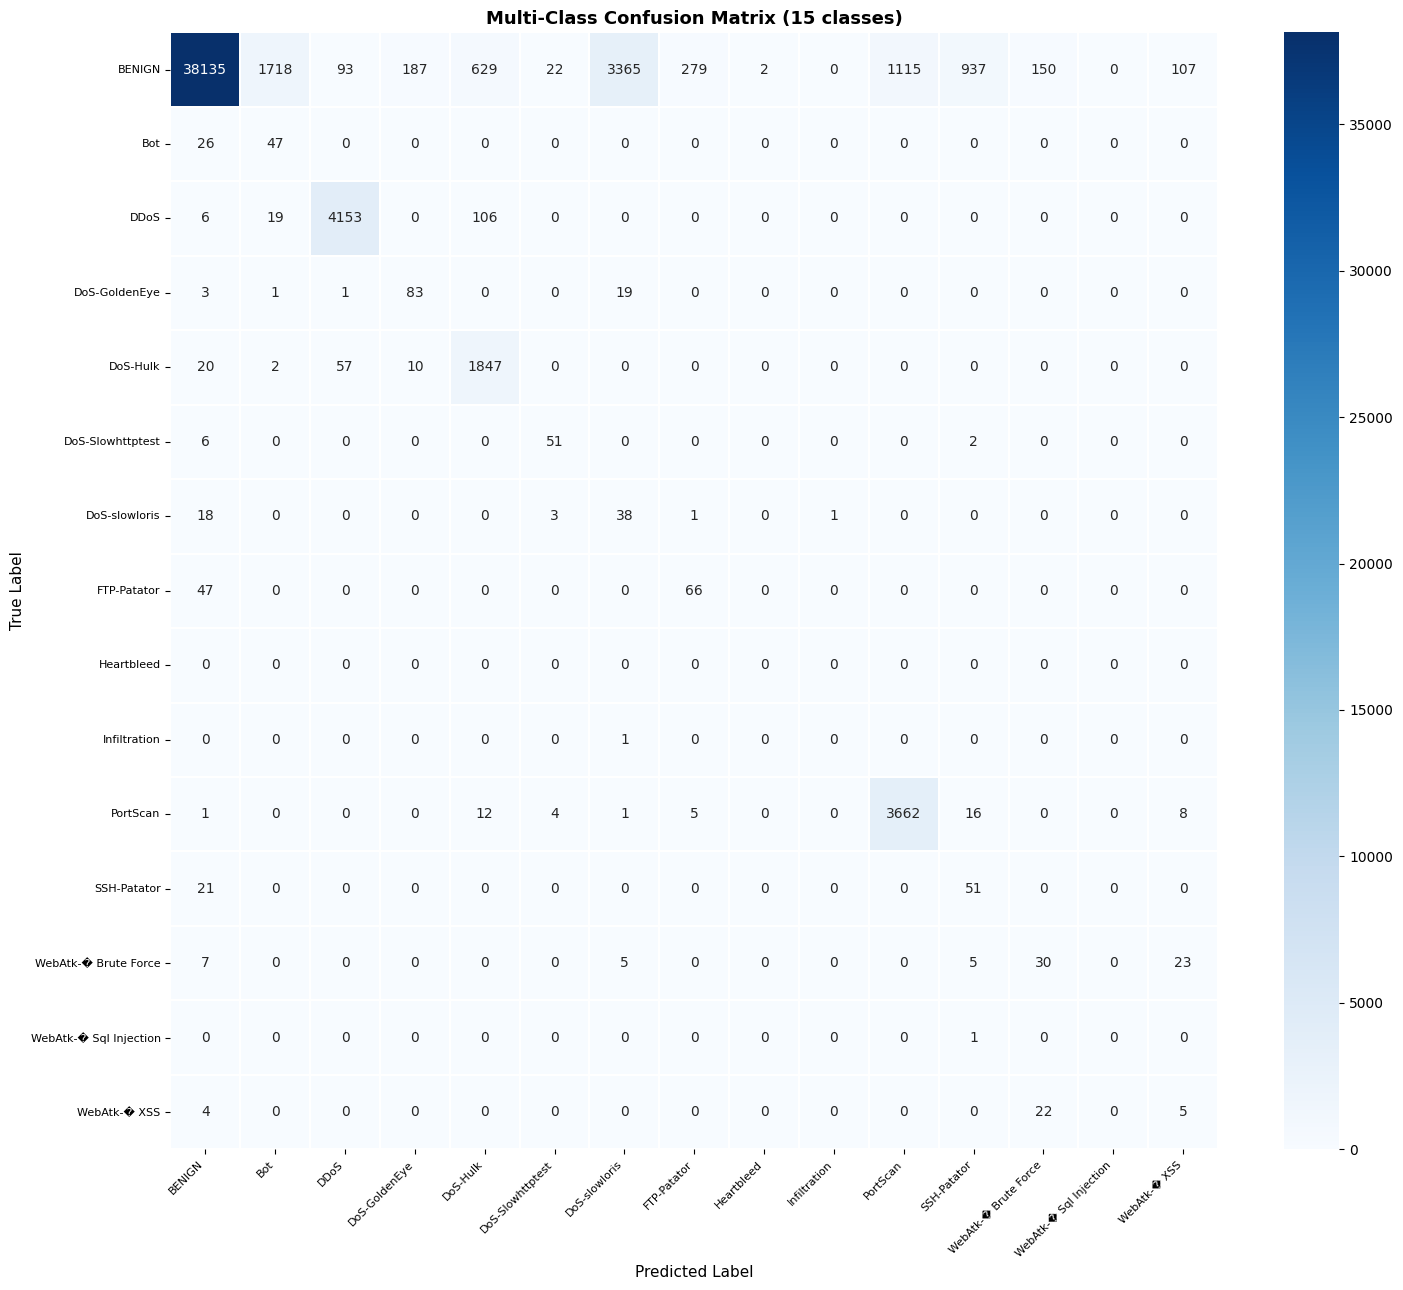

Per-Class Detection Summary:
Class                                           True  Detected  Missed   Recall
────────────────────────────────────────────────────────────────────────────────
BENIGN                                        46,739    38,135   8,604    81.6%
Bot                                               73        47      26    64.4% ← LOW
DDoS                                           4,284     4,153     131    96.9%
DoS GoldenEye                                    107        83      24    77.6% ← LOW
DoS Hulk                                       1,936     1,847      89    95.4%
DoS Slowhttptest                                  59        51       8    86.4%
DoS slowloris                                     61        38      23    62.3% ← LOW
FTP-Patator                                      113        66      47    58.4% ← LOW
Heartbleed                                         0         0       0     0.0% ← LOW
Infiltration                                       1        

In [ ]:
# ---- Multi-Class Confusion Matrix ----
cm = confusion_matrix(y_true, y_pred, labels=list(range(N_CLASSES)))

# Use short class names for readability on the plot
short_names = [n.replace('Web Attack ', 'WebAtk-').replace('DoS ', 'DoS-') for n in CLASS_NAMES]

fig, ax = plt.subplots(figsize=(max(10, N_CLASSES), max(8, N_CLASSES - 2)))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=short_names,
    yticklabels=short_names,
    ax=ax, linewidths=0.3
)
ax.set_title(f'Multi-Class Confusion Matrix ({N_CLASSES} classes)', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

# ---- Print per-class detection summary ----
print('Per-Class Detection Summary:')
print(f'{"Class":<45} {"True":>6} {"Detected":>9} {"Missed":>7} {"Recall":>8}')
print('─' * 80)
for i, name in enumerate(CLASS_NAMES):
    true_count    = int((y_true == i).sum())
    detected      = int(cm[i, i])
    missed        = true_count - detected
    recall        = detected / true_count if true_count > 0 else 0.0
    flag          = '' if recall >= 0.8 else ' ← LOW'
    print(f'{name:<45} {true_count:>6,} {detected:>9,} {missed:>7,} {recall*100:>7.1f}%{flag}')

In [ ]:
print('=== MULTI-CLASS CLASSIFICATION REPORT ===')
print('(Per-class Precision, Recall, F1-Score and Support)\n')
print(classification_report(
    y_true, y_pred,
    labels=list(range(N_CLASSES)),
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
))
print()
print('Metric Definitions:')
print('  Precision : Of all flows predicted as this class, what fraction truly belonged to it?')
print('  Recall    : Of all actual flows of this class, what fraction did the model detect?')
print('  F1-Score  : Harmonic mean of Precision and Recall — best single metric for imbalanced data')
print('  Support   : Number of true instances of this class in the test set')

=== MULTI-CLASS CLASSIFICATION REPORT ===
(Per-class Precision, Recall, F1-Score and Support)

                            precision    recall  f1-score   support

                    BENIGN     0.9958    0.8159    0.8969     46739
                       Bot     0.0263    0.6438    0.0505        73
                      DDoS     0.9649    0.9694    0.9672      4284
             DoS GoldenEye     0.2964    0.7757    0.4289       107
                  DoS Hulk     0.7120    0.9540    0.8155      1936
          DoS Slowhttptest     0.6375    0.8644    0.7338        59
             DoS slowloris     0.0111    0.6230    0.0218        61
               FTP-Patator     0.1880    0.5841    0.2845       113
                Heartbleed     0.0000    0.0000    0.0000         0
              Infiltration     0.0000    0.0000    0.0000         1
                  PortScan     0.7666    0.9873    0.8631      3709
               SSH-Patator     0.0504    0.7083    0.0941        72
  Web Attack � Brute

In [ ]:
# ---- Multi-Class IDS Performance Metrics ----
from sklearn.metrics import matthews_corrcoef, recall_score, precision_score

# Overall metrics
overall_acc   = accuracy_score(y_true, y_pred)
overall_f1mac = f1_score(y_true, y_pred, average='macro',    zero_division=0)
overall_f1wt  = f1_score(y_true, y_pred, average='weighted', zero_division=0)
overall_mcc   = matthews_corrcoef(y_true, y_pred)

# Attack-focused metrics (BENIGN vs all attacks combined)
attack_mask_true = (y_true != BENIGN_IDX)
attack_mask_pred = (y_pred != BENIGN_IDX)

TP_attack = int(( attack_mask_true &  attack_mask_pred).sum())
FP_attack = int((~attack_mask_true &  attack_mask_pred).sum())
FN_attack = int(( attack_mask_true & ~attack_mask_pred).sum())
TN_attack = int((~attack_mask_true & ~attack_mask_pred).sum())

detection_rate   = TP_attack / (TP_attack + FN_attack) if (TP_attack + FN_attack) > 0 else 0
false_alarm_rate = FP_attack / (FP_attack + TN_attack) if (FP_attack + TN_attack) > 0 else 0
precision_attack = TP_attack / (TP_attack + FP_attack) if (TP_attack + FP_attack) > 0 else 0
error_rate       = (FP_attack + FN_attack) / len(y_true)

print('=' * 65)
print('      FINAL IDS PERFORMANCE METRICS (Multi-Class)')
print('=' * 65)

# ---- PRIMARY METRIC: MCC (best for imbalanced datasets) ----
print()
print(f'  >>> PRIMARY METRIC <<<')
print(f'  Matthews Corr. Coeff.   : {overall_mcc:.4f}')
print(f'    (MCC is the best single metric for imbalanced data — ranges')
print(f'     from -1 to +1, where +1 = perfect, 0 = random, -1 = inverse)')
print()
print(f'  Macro F1-Score          : {overall_f1mac*100:.2f}%  (unweighted avg across ALL classes)')
print(f'  Overall Accuracy        : {overall_acc*100:.2f}%')
print(f'  Weighted F1-Score       : {overall_f1wt*100:.2f}%')

# ---- PER-CLASS RECALL (critical for IDS — can we catch each attack type?) ----
print()
print('  -- Per-Class Recall (Attack Detection Ability) --')
print(f'  {"Class":<45} {"Recall":>8}  {"Support":>8}  Status')
print('  ' + '-' * 75)
from collections import Counter
cm_diag = confusion_matrix(y_true, y_pred, labels=list(range(N_CLASSES)))
true_counts = Counter(y_true.tolist())
low_recall_classes = []
for idx, name in enumerate(CLASS_NAMES):
    cnt = true_counts.get(idx, 0)
    if cnt > 0:
        recall = cm_diag[idx, idx] / cm_diag[idx].sum()
        status = 'OK' if recall >= 0.80 else 'LOW' if recall >= 0.50 else 'CRITICAL'
        flag = '' if status == 'OK' else f'  <-- {status}'
        print(f'  [{idx:>2}] {name:<42} {recall*100:>7.1f}%  {cnt:>8,}  {flag}')
        if recall < 0.50:
            low_recall_classes.append((name, recall))
    else:
        print(f'  [{idx:>2}] {name:<42}     N/A  {cnt:>8,}  (no test samples)')

if low_recall_classes:
    print()
    print(f'  WARNING: {len(low_recall_classes)} class(es) have recall < 50%:')
    for name, r in low_recall_classes:
        print(f'    - {name}: {r*100:.1f}% (model fails to detect most instances)')

# ---- Attack Detection Summary ----
print()
print('  -- Attack Detection Summary (Binary: Attack vs Benign) --')
print(f'  Detection Rate (Recall) : {detection_rate*100:.2f}%')
print(f'  Precision (Attacks)     : {precision_attack*100:.2f}%')
print(f'  False Alarm Rate        : {false_alarm_rate*100:.2f}%')
print(f'  Error Rate              : {error_rate*100:.2f}%')
print()
print(f'  TP: {TP_attack:>6,}  (attacks correctly detected)')
print(f'  FP: {FP_attack:>6,}  (benign wrongly flagged)')
print(f'  FN: {FN_attack:>6,}  (attacks missed)')
print(f'  TN: {TN_attack:>6,}  (benign correctly passed)')
print('=' * 65)


      FINAL IDS PERFORMANCE METRICS (Multi-Class)

  >>> PRIMARY METRIC <<<
  Matthews Corr. Coeff.   : 0.6814
    (MCC is the best single metric for imbalanced data — ranges
     from -1 to +1, where +1 = perfect, 0 = random, -1 = inverse)

  Macro F1-Score          : 36.23%  (unweighted avg across ALL classes)
  Overall Accuracy        : 84.13%
  Weighted F1-Score       : 89.07%

  -- Per-Class Recall (Attack Detection Ability) --
  Class                                           Recall   Support  Status
  ---------------------------------------------------------------------------
  [ 0] BENIGN                                        81.6%    46,739  
  [ 1] Bot                                           64.4%        73    <-- LOW
  [ 2] DDoS                                          96.9%     4,284  
  [ 3] DoS GoldenEye                                 77.6%       107    <-- LOW
  [ 4] DoS Hulk                                      95.4%     1,936  
  [ 5] DoS Slowhttptest              

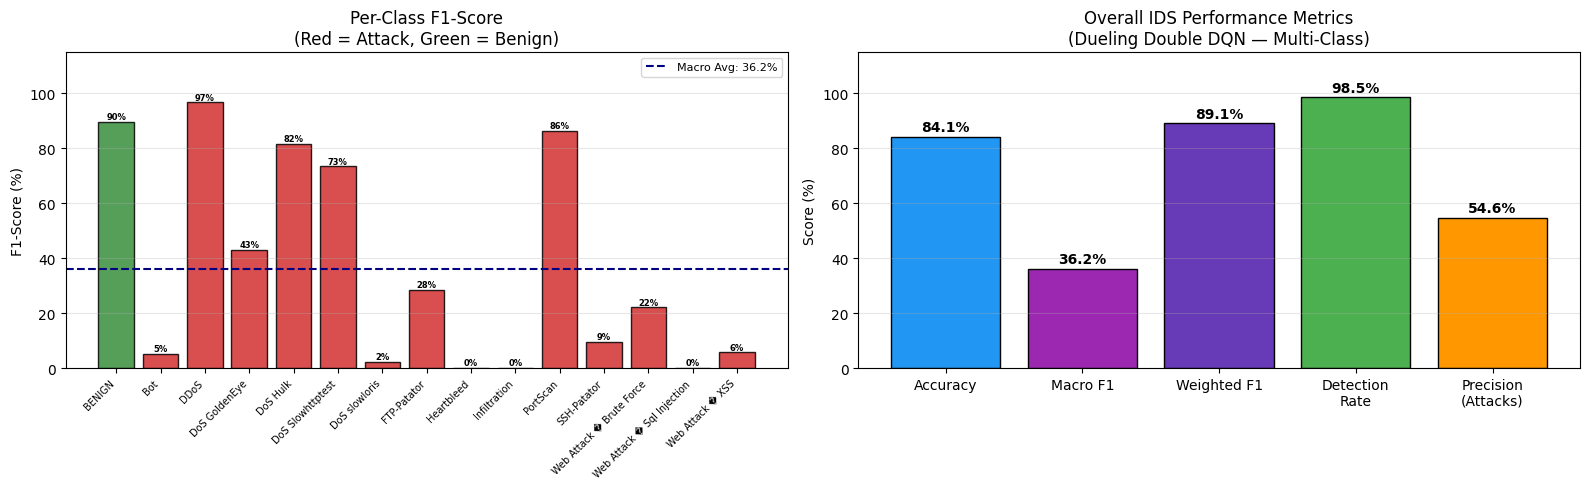

In [ ]:
# ---- Per-Class F1-Score Bar Chart ----
from sklearn.metrics import f1_score as f1_per_class

per_class_f1 = f1_score(y_true, y_pred, average=None, labels=list(range(N_CLASSES)), zero_division=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: Per-class F1
colors = ['#d32f2f' if i != BENIGN_IDX else '#388e3c' for i in range(N_CLASSES)]
bars = axes[0].bar(range(N_CLASSES), per_class_f1 * 100, color=colors, edgecolor='black', alpha=0.85)
axes[0].set_xticks(range(N_CLASSES))
axes[0].set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=7)
axes[0].set_ylim(0, 115)
axes[0].set_ylabel('F1-Score (%)')
axes[0].set_title('Per-Class F1-Score\n(Red = Attack, Green = Benign)')
axes[0].axhline(y=overall_f1mac * 100, color='navy', linestyle='--', linewidth=1.5, label=f'Macro Avg: {overall_f1mac*100:.1f}%')
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, per_class_f1 * 100):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.0f}%', ha='center', fontsize=6, fontweight='bold')

# Right: Overall summary metrics
summary_names = ['Accuracy', 'Macro F1', 'Weighted F1', 'Detection\nRate', 'Precision\n(Attacks)']
summary_vals  = [overall_acc*100, overall_f1mac*100, overall_f1wt*100, detection_rate*100, precision_attack*100]
summary_cols  = ['#2196F3', '#9C27B0', '#673AB7', '#4CAF50', '#FF9800']
bars2 = axes[1].bar(summary_names, summary_vals, color=summary_cols, edgecolor='black')
axes[1].set_ylim(0, 115)
axes[1].set_title('Overall IDS Performance Metrics\n(Dueling Double DQN — Multi-Class)')
axes[1].set_ylabel('Score (%)')
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, summary_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Model Saving with Versioning
# ============================================================
from datetime import datetime
import json as _json
import os
import pickle
import time as _time

VERSION = datetime.now().strftime('%Y%m%d_%H%M%S')
SAVE_PATH = f'/content/drive/MyDrive/IDS_Models/v_{VERSION}'
os.makedirs(SAVE_PATH, exist_ok=True)

# ---- Save models ----
encoder.save(f'{SAVE_PATH}/encoder.keras')
dqn_model.save(f'{SAVE_PATH}/dqn_model.keras')
classifier.save(f'{SAVE_PATH}/classifier.keras')

with open(f'{SAVE_PATH}/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open(f'{SAVE_PATH}/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

with open(f'{SAVE_PATH}/class_names.pkl', 'wb') as f:
    pickle.dump(CLASS_NAMES, f)

with open(f'{SAVE_PATH}/class_weights.pkl', 'wb') as f:
    pickle.dump(CLASS_WEIGHTS, f)

# ---- Save metadata ----
metadata = {
    'version': VERSION,
    'n_classes': N_CLASSES,
    'class_names': CLASS_NAMES,
    'input_features': int(X_train.shape[1]),
    'encoded_features': int(X_train_enc.shape[1]),
    'train_samples': int(len(X_train)),
    'test_samples': int(len(X_test)),
    'dqn_episodes': len(reward_history),
    'metrics': {
        'accuracy': float(overall_acc),
        'macro_f1': float(overall_f1mac),
        'weighted_f1': float(overall_f1wt),
        'mcc': float(overall_mcc),
        'detection_rate': float(detection_rate),
        'false_alarm_rate': float(false_alarm_rate),
    }
}
with open(f'{SAVE_PATH}/metadata.json', 'w') as f:
    _json.dump(metadata, f, indent=2)

# ---- Inference latency benchmark ----
n_bench = min(5000, len(X_test))
bench_raw = X_test[:n_bench]

# Warm up
_ = encoder.predict(bench_raw[:10], verbose=0)
_ = dqn_model.predict(X_test_enc[:10], verbose=0)
_ = classifier.predict(feature_extractor.predict(X_test_enc[:10], verbose=0), verbose=0)

# Benchmark full pipeline: scale -> encode -> DQN features -> classifier
t0 = _time.time()
bench_enc  = encoder.predict(bench_raw, batch_size=4096, verbose=0)
bench_feat = feature_extractor.predict(bench_enc, batch_size=4096, verbose=0)
bench_pred = classifier.predict(bench_feat, batch_size=4096, verbose=0)
t1 = _time.time()

throughput = n_bench / (t1 - t0)
latency_ms = (t1 - t0) / n_bench * 1000

print(f'Models saved to: {SAVE_PATH}')
print(f'  encoder.keras      -- Feature compression ({X_train.shape[1]} -> {encoding_dim})')
print(f'  dqn_model.keras    -- DQN feature extractor')
print(f'  classifier.keras   -- Supervised classification head ({N_CLASSES}-class)')
print(f'  scaler.pkl         -- MinMax scaler for new data')
print(f'  label_encoder.pkl  -- Maps class indices -> names')
print(f'  class_names.pkl    -- Ordered class name list')
print(f'  class_weights.pkl  -- Class weights for reward scaling')
print(f'  metadata.json      -- Version, metrics, and config')
print()
print(f'Version     : {VERSION}')
print(f'Metrics     : Acc={overall_acc*100:.1f}%, MacroF1={overall_f1mac*100:.1f}%, MCC={overall_mcc:.3f}')
print()
print(f'Inference Benchmark ({n_bench:,} flows):')
print(f'  Throughput : {throughput:,.0f} flows/sec')
print(f'  Latency    : {latency_ms:.2f} ms/flow')

# ---- Production inference function ----
def predict_flow(raw_features):
    """
    Full pipeline: raw 78-dim features -> class name.
    Pipeline: Scale -> Encode -> DQN Features -> Classifier -> Prediction
    """
    single = raw_features.ndim == 1
    if single:
        raw_features = raw_features.reshape(1, -1)

    scaled  = scaler.transform(raw_features).astype(np.float32)
    encoded = encoder.predict(scaled, verbose=0)
    feats   = feature_extractor.predict(encoded, verbose=0)
    probs   = classifier.predict(feats, verbose=0)
    pred_idx = np.argmax(probs, axis=1)
    names = [CLASS_NAMES[i] for i in pred_idx]

    return names[0] if single else names

print()
print('predict_flow() defined for production inference.')
print('Pipeline: Raw(78) -> Scale -> Encode -> DQN Features -> Classifier -> Class Name')
print('Usage: predict_flow(np.array([...78 raw features...]))')


Models saved to: /content/drive/MyDrive/IDS_Models/v_20260410_175951
  encoder.keras      -- Feature compression (78 -> 29)
  dqn_model.keras    -- DQN feature extractor
  classifier.keras   -- Supervised classification head (15-class)
  scaler.pkl         -- MinMax scaler for new data
  label_encoder.pkl  -- Maps class indices -> names
  class_names.pkl    -- Ordered class name list
  class_weights.pkl  -- Class weights for reward scaling
  metadata.json      -- Version, metrics, and config

Version     : 20260410_175951
Metrics     : Acc=84.1%, MacroF1=36.2%, MCC=0.681

Inference Benchmark (5,000 flows):
  Throughput : 3,718 flows/sec
  Latency    : 0.27 ms/flow

predict_flow() defined for production inference.
Pipeline: Raw(78) -> Scale -> Encode -> DQN Features -> Classifier -> Class Name
Usage: predict_flow(np.array([...78 raw features...]))


In [ ]:
# ============================================================
# LOAD SAVED MODELS & PREDICT ON NEW DATA
# ============================================================
import numpy as np
import pickle
import json
from tensorflow import keras

# ---- Set your saved model path ----
SAVE_PATH = '/content/drive/MyDrive/IDS_Models/v_XXXXXXXX_XXXXXX'  # <-- change this

# ---- Load everything ----
encoder     = keras.models.load_model(f'{SAVE_PATH}/encoder.keras')
dqn_model   = keras.models.load_model(f'{SAVE_PATH}/dqn_model.keras')
classifier  = keras.models.load_model(f'{SAVE_PATH}/classifier.keras')

with open(f'{SAVE_PATH}/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

with open(f'{SAVE_PATH}/label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

with open(f'{SAVE_PATH}/class_names.pkl', 'rb') as f:
    CLASS_NAMES = pickle.load(f)

with open(f'{SAVE_PATH}/metadata.json', 'r') as f:
    metadata = json.load(f)

# ---- Build feature extractor from DQN ----
feature_extractor = keras.Model(
    inputs=dqn_model.input,
    outputs=dqn_model.layers[-7].output
)

print(f'Models loaded from: {SAVE_PATH}')
print(f'Version: {metadata["version"]}')
print(f'Classes: {metadata["n_classes"]}')
print(f'Saved metrics: Acc={metadata["metrics"]["accuracy"]*100:.1f}%, MCC={metadata["metrics"]["mcc"]:.3f}')

# ---- Predict function ----
def predict_flow(raw_features):
    """
    Input:  raw 78-dim features (single sample or batch)
    Output: predicted class name(s)
    Pipeline: Scale -> Encode -> DQN Features -> Classifier
    """
    single = raw_features.ndim == 1
    if single:
        raw_features = raw_features.reshape(1, -1)

    scaled  = scaler.transform(raw_features).astype(np.float32)
    encoded = encoder.predict(scaled, verbose=0)
    feats   = feature_extractor.predict(encoded, verbose=0)
    probs   = classifier.predict(feats, verbose=0)
    pred_idx = np.argmax(probs, axis=1)
    names = [CLASS_NAMES[i] for i in pred_idx]

    return names[0] if single else names

# ---- Example usage ----
# Single sample:
# result = predict_flow(np.array([...78 values...]))
# print(result)  # e.g. 'DDoS'

# Batch from CSV:
# import pandas as pd
# df_new = pd.read_csv('new_traffic.csv')
# features = df_new.drop(columns=['Label']).values.astype(np.float32)
# predictions = predict_flow(features)
# df_new['Predicted'] = predictions
# df_new.to_csv('predictions_output.csv', index=False)

print('\nReady! Use predict_flow(raw_78_features) to classify network traffic.')
